<a href="https://colab.research.google.com/github/kanokwantho/SC663402_Pandas_Review.ipynb/blob/main/673020243_5_%E0%B8%81%E0%B8%99%E0%B8%81%E0%B8%A7%E0%B8%A3%E0%B8%A3%E0%B8%93_%E0%B8%97%E0%B8%AD%E0%B8%87%E0%B9%80%E0%B8%97%E0%B8%9E__SC663402_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

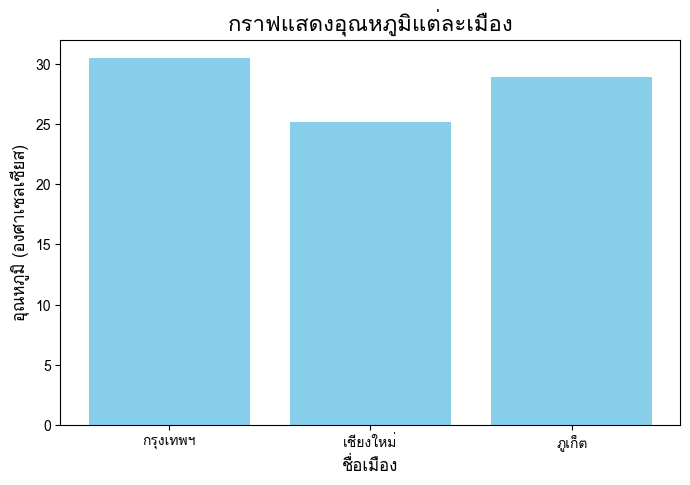

In [1]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [2]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [3]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [4]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [5]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [6]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [7]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [8]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


คำสั่งทั้ง 6 เซลล์มีลักษณะใกล้เคียงกันแต่มีความแตกต่างด้านวิธีเลือกข้อมูล ชนิดของผลลัพธ์ รูปร่างของผลลัพธ์ และความหมายของค่าที่ได้ โดย loc ใช้เลือกข้อมูลตาม label ส่วน iloc ใช้เลือกตามตำแหน่ง และ loc จะรวมตำแหน่งปลายช่วงในการ slicing ขณะที่ iloc ไม่รวมปลายช่วง นอกจากนี้ df["city"] จะคืนค่าเป็น Series ซึ่งมีมิติเดียว ในขณะที่ df[["city"]] จะคืนค่าเป็น DataFrame ซึ่งมีสองมิติ แม้จะมีข้อมูลเพียงหนึ่งคอลัมน์ก็ตาม

สำหรับการจัดกลุ่ม count() จะนับเฉพาะค่าที่ไม่เป็น missing ในขณะที่ size() จะนับจำนวนแถวทั้งหมดรวมถึงแถวที่มีค่า missing ดังนั้นควรใช้ count() เมื่อต้องการทราบจำนวนข้อมูลที่มีค่าจริง และใช้ size() เมื่อต้องการทราบจำนวน record ในแต่ละกลุ่ม ส่วน groupby() ที่เลือกคอลัมน์เป็น Series จะได้ผลลัพธ์เป็น Series ขณะที่การเลือกคอลัมน์ในรูป DataFrame จะได้ผลลัพธ์เป็น DataFrame

สำหรับการคำนวณระหว่าง Series การใช้ a + b จะจับคู่ข้อมูลตาม index ซึ่งช่วยป้องกันการจับคู่ข้อมูลผิดเมื่อข้อมูลมีลำดับแตกต่างกัน แต่การใช้ to_numpy() จะเปลี่ยนข้อมูลเป็น NumPy array และคำนวณตามตำแหน่ง ดังนั้นในการใช้งานจริงควรเลือกคำสั่งให้สอดคล้องกับลักษณะของข้อมูลและผลลัพธ์ที่ต้องการ โดยเฉพาะต้องพิจารณาว่าต้องการทำงานตาม label หรือตำแหน่ง ต้องการ Series หรือ DataFrame และต้องการนับเฉพาะค่าที่มีข้อมูลหรือทุกแถวค่ะ


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [10]:
# คำตอบข้อ 2.1

# 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

print("--- 3 เมืองที่มีปริมาณฝนรวมสูงสุด (มม.) ---")
print(rain_by_city.nlargest(3))
print("\n" + "="*40 + "\n")

# 2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด (%)
rain_share = (rain_by_city / rain_by_city.sum() * 100).round(2)

print("--- สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับรวมทั้งหมด (%) ---")
print(rain_share)
print("\n" + "="*40 + "\n")

# 3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง
avg_rain = rain_by_city.mean()
n_above_avg = (rain_by_city > avg_rain).sum()

print("--- จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง ---")
print(f"ค่าเฉลี่ยปริมาณฝนรวมทุกเมือง: {avg_rain:.2f} มม.")
print(f"จำนวนเมืองที่สูงกว่าค่าเฉลี่ย: {n_above_avg} เมือง")

--- 3 เมืองที่มีปริมาณฝนรวมสูงสุด (มม.) ---
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64


--- สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับรวมทั้งหมด (%) ---
city
Auckland         4.22
Bangkok          8.21
Beijing          3.00
Berlin           3.21
Buenos Aires     3.65
Cairo            1.47
Cape Town        2.87
Chiang Mai       5.22
Lagos            7.82
Lima             2.16
London           3.27
Los Angeles      2.03
Mexico City      3.66
Moscow           2.96
Mumbai           5.84
Nairobi          4.74
New York         3.78
Paris            3.99
Sao Paulo        5.07
Singapore       10.43
Sydney           3.97
Tokyo            4.61
Toronto          3.81
Name: rainfall_mm, dtype: float64


--- จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง ---
ค่าเฉลี่ยปริมาณฝนรวมทุกเมือง: 362.97 มม.
จำนวนเมืองที่สูงกว่าค่าเฉลี่ย: 8 เมือง


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [12]:
# คำตอบข้อ 2.2
city_profile = (
    df.groupby("city")
      .agg(
          country=("country", "first"),
          region=("region", "first"),
          n_records=("city", "size"),
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum")
      )
      .reset_index()
)

print(city_profile)

            city       country         region  n_records   avg_temp  \
0       Auckland   New Zealand        Oceania         90  17.804444   
1        Bangkok      Thailand           Asia         91  32.453846   
2        Beijing         China           Asia         90  15.598876   
3         Berlin       Germany         Europe         90  12.383146   
4   Buenos Aires     Argentina  South America         90  19.171910   
5          Cairo         Egypt         Africa         91  26.089888   
6      Cape Town  South Africa         Africa         90  30.162921   
7     Chiang Mai      Thailand           Asia         91  29.680220   
8          Lagos       Nigeria         Africa         90  29.494253   
9           Lima          Peru  South America         90  21.490000   
10        London            UK         Europe         90  13.490909   
11   Los Angeles           USA  North America         90  20.657303   
12   Mexico City        Mexico  North America         90  19.187778   
13    

---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [13]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [14]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [15]:
# คำตอบข้อ 3.1
df3 = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date",
        "city",
        "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={
        "city": "category",
        "region": "category"
    },
    index_col="city"
)

print(df3.dtypes)
df3.info()

date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [18]:
# ตารางปกติ
normal = pd.read_csv(BASE + "world_weather_sample.csv")

# ตาราง Optimized จากข้อ 3.1
optimized = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date", "city", "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={
        "city": "category",
        "region": "category"
    }
)

# คำนวณ Memory รวม
mem_normal = normal.memory_usage(deep=True).sum()
mem_optimized = optimized.memory_usage(deep=True).sum()

# คำนวณเปอร์เซ็นต์ที่ลดลง
reduction = (mem_normal - mem_optimized) / mem_normal * 100

print("Normal:", mem_normal, "bytes")
print("Optimized:", mem_optimized, "bytes")
print("ลดลง:", round(reduction, 2), "%")


# ดู Memory ของแต่ละคอลัมน์
print("\nMemory ของแต่ละคอลัมน์ - Normal")
print(normal.memory_usage(deep=True))

print("\nMemory ของแต่ละคอลัมน์ - Optimized")
print(optimized.memory_usage(deep=True))

Normal: 571645 bytes
Optimized: 73049 bytes
ลดลง: 87.22 %

Memory ของแต่ละคอลัมน์ - Normal
Index                132
record_id          16600
date              122425
city              116920
country           114937
region            117631
temperature_c      16600
humidity_pct       16600
rainfall_mm        16600
wind_speed_kmh     16600
pressure_hpa       16600
dtype: int64

Memory ของแต่ละคอลัมน์ - Optimized
Index              132
date             16600
city              3927
region            2590
temperature_c    16600
humidity_pct     16600
rainfall_mm      16600
dtype: int64


จากการเปรียบเทียบพบว่า ตาราง Normal ใช้หน่วยความจำ 571,645 bytes ขณะที่ตาราง Optimized ใช้เพียง 73,049 bytes ทำให้หน่วยความจำลดลง 87.22% โดยคอลัมน์ที่มีผลต่อการลดลงอย่างชัดเจนคือ city และ region เนื่องจากในตาราง Optimized กำหนดให้ทั้งสองคอลัมน์เป็นชนิดข้อมูล category ซึ่งเหมาะกับข้อมูลที่มีค่าซ้ำกันจำนวนมาก ทำให้ Pandas ไม่ต้องเก็บข้อความซ้ำทุกแถวและใช้รหัสอ้างอิงแทน จึงลดการใช้หน่วยความจำจาก city 116,920 เหลือ 3,927 bytes และ region 117,631 เหลือ 2,590 bytes นอกจากนี้ การใช้ usecols ยังช่วยลดหน่วยความจำโดยการตัดคอลัมน์ที่ไม่จำเป็นออกไปด้วย


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [19]:
# คำตอบข้อ 3.3

#อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
# อ่านข้อมูลทีละก้อน
chunksize = 500

max_temp = float("-inf")
min_temp = float("inf")

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    chunksize=chunksize
):
    # คำนวณค่าสูงสุดและต่ำสุดของแต่ละก้อน
    chunk_max = chunk["temperature_c"].max()
    chunk_min = chunk["temperature_c"].min()

    # สะสมค่าสูงสุดและต่ำสุด
    max_temp = max(max_temp, chunk_max)
    min_temp = min(min_temp, chunk_min)

print("อุณหภูมิสูงสุด:", max_temp)
print("อุณหภูมิต่ำสุด:", min_temp)

อุณหภูมิสูงสุด: 999.0
อุณหภูมิต่ำสุด: -88.0


In [20]:
#อุณหภูมิเฉลี่ยรายเมือง
chunksize = 500

# เก็บผลรวมอุณหภูมิและจำนวนข้อมูลของแต่ละเมือง
city_sum = {}
city_count = {}

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    chunksize=chunksize
):
    # คำนวณผลรวมและจำนวนข้อมูลแยกตามเมืองในแต่ละ chunk
    grouped = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])

    for city, row in grouped.iterrows():

        # ถ้ายังไม่เคยเจอเมืองนี้
        if city not in city_sum:
            city_sum[city] = 0
            city_count[city] = 0

        # สะสมผลรวมและจำนวนข้อมูล
        city_sum[city] += row["sum"]
        city_count[city] += row["count"]


# คำนวณค่าเฉลี่ยสุดท้ายของแต่ละเมือง
city_mean = {}

for city in city_sum:
    city_mean[city] = city_sum[city] / city_count[city]

print("อุณหภูมิเฉลี่ยรายเมือง")

for city, mean in city_mean.items():
    print(city, ":", round(mean, 2))

อุณหภูมิเฉลี่ยรายเมือง
Auckland : 17.8
Bangkok : 32.45
Beijing : 15.6
Berlin : 12.38
Buenos Aires : 19.17
Cairo : 26.09
Cape Town : 30.16
Chiang Mai : 29.68
Lagos : 29.49
Lima : 21.49
London : 13.49
Los Angeles : 20.66
Mexico City : 19.19
Moscow : 7.23
Mumbai : 30.87
Nairobi : 21.44
New York : 15.48
Paris : 25.81
Sao Paulo : 22.84
Singapore : 40.08
Sydney : 20.35
Tokyo : 18.41
Toronto : 11.61


พราะแต่ละก้อนอาจมี จำนวนข้อมูลไม่เท่ากัน การนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันจึงให้น้ำหนักแต่ละก้อนเท่ากัน ทำให้ผลคลาดเคลื่อน

ควรสะสม ผลรวม (sum) และจำนวนข้อมูล (count) แล้วคำนวณ


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [22]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [23]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [24]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": df.isna().mean() * 100,
    "n_unique": df.nunique(),
    "example_value": df.apply(
        lambda s: s.dropna().iloc[0]
        if s.notna().any() else np.nan
    )
})

summary = summary.sort_values(
    "n_missing",
    ascending=False
)

print(summary)

                  dtype  n_missing  pct_missing  n_unique  example_value
humidity_pct    float64         82     3.951807       544           72.6
rainfall_mm     float64         62     2.987952       164            6.3
wind_speed_kmh  float64         41     1.975904       278           15.9
pressure_hpa    float64         32     1.542169       294         1005.4
temperature_c   float64         20     0.963855       331           15.7
record_id         int64          0     0.000000      2070            983
date             object          0     0.000000        90     2025-03-24
region           object          0     0.000000         6  North America
city             object          0     0.000000        23       New York
country          object          0     0.000000        28            USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [26]:
# 1. อุณหภูมินอกช่วง -60 ถึง 60
temp_abnormal = (df["temperature_c"] < -60) | (df["temperature_c"] > 60)

# 2. ความชื้นนอกช่วง 0 ถึง 100
humidity_abnormal = (df["humidity_pct"] < 0) | (df["humidity_pct"] > 100)

# 3. แถวที่ผิดปกติอย่างน้อย 1 คอลัมน์
any_abnormal = temp_abnormal | humidity_abnormal

print("1. temperature_c ผิดปกติ:", temp_abnormal.sum())
print("2. humidity_pct ผิดปกติ:", humidity_abnormal.sum())
print("3. ผิดปกติอย่างน้อย 1 คอลัมน์:", any_abnormal.sum())

1. temperature_c ผิดปกติ: 5
2. humidity_pct ผิดปกติ: 3
3. ผิดปกติอย่างน้อย 1 คอลัมน์: 8


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [28]:
# ==========================================
# การตรวจสอบและทำความสะอาดข้อมูลคอลัมน์ country
# ==========================================

# 1. ตัดช่องว่างส่วนเกินและแปลงเป็นตัวพิมพ์เล็กทั้งหมด เพื่อใช้เป็นมาตรฐานในการตรวจสอบ
country_check = df["country"].str.strip().str.lower()

# 2. แสดงกลุ่มของชื่อประเทศที่อาจเขียนสะกดต่างกัน แต่มีความหมายเดียวกัน
print("--- รายชื่อประเทศที่จัดกลุ่มตามรูปแบบที่เป็นมาตรฐาน ---")
print(df.groupby(country_check)["country"].unique())
print("\n" + "="*50 + "\n")

# 3. แสดงรายชื่อประเทศที่ไม่ซ้ำกัน โดยปรับให้ตัวอักษรตัวแรกเป็นพิมพ์ใหญ่ (Title Case)
print("--- รายชื่อประเทศที่ไม่ซ้ำกัน (รูปแบบ Title Case) ---")
print(df["country"].str.title().unique())
print("\n" + "="*50 + "\n")

# 4. สร้างคอลัมน์ใหม่สำหรับเก็บข้อมูลประเทศที่ผ่านการทำความสะอาดแล้ว
df["country_normalized"] = (
    df["country"]
    .str.strip()
    .str.lower()
)

# 5. แสดงจำนวนประเทศทั้งหมดที่ไม่ซ้ำกันหลังจากทำความสะอาดข้อมูลแล้ว
print("จำนวนประเทศที่ไม่ซ้ำกันทั้งหมด:", df["country_normalized"].nunique())

--- รายชื่อประเทศที่จัดกลุ่มตามรูปแบบที่เป็นมาตรฐาน ---
country
argentina           [Argentina, ARGENTINA]
australia                      [Australia]
brazil                            [Brazil]
canada                    [Canada, CANADA]
china                              [China]
egypt                              [Egypt]
france                            [France]
germany                 [Germany, GERMANY]
india                              [India]
japan                       [Japan, JAPAN]
kenya                       [Kenya, KENYA]
mexico                            [Mexico]
new zealand     [New Zealand, NEW ZEALAND]
nigeria                          [Nigeria]
peru                                [Peru]
russia                            [Russia]
singapore           [Singapore, SINGAPORE]
south africa                [South Africa]
thailand                        [Thailand]
uk                                    [UK]
usa                                  [USA]
Name: country, dtype: object


--

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [29]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [30]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 9)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [31]:
# คำตอบข้อ 5.1
# 1. แถวตำแหน่งเลขคู่ 10 แถวแรก และ 3 คอลัมน์สุดท้าย
print(df.iloc[0:20:2, -3:])


# 2. 5 แถวสุดท้าย เรียงจากแถวล่างสุดขึ้นไป
print(df.iloc[-1:-6:-1])


# 3. ค่าเดี่ยวที่อยู่แถวกึ่งกลาง และคอลัมน์สุดท้าย
middle = len(df) // 2
print(df.iloc[middle, -1])


    wind_speed_kmh  pressure_hpa country_normalized
0             15.9        1005.4                usa
2              8.6        1013.5                usa
4             16.6        1015.1       south africa
6             14.6        1018.0          argentina
8              9.8        1007.7          argentina
10            15.6        1010.1             russia
12            13.6        1015.8              china
14            24.6        1000.5          argentina
16             9.3        1019.4          argentina
18            23.3        1020.6            nigeria
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

      temperature_c  humi

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [32]:
# คำตอบข้อ 5.2
# กำหนด MultiIndex เป็น (region, city) และเรียงลำดับ index
df = df.set_index(["region", "city"]).sort_index()


# 1. ข้อมูลทั้งหมดของภูมิภาค Asia
#    เฉพาะคอลัมน์ date และ temperature_c
print(df.loc["Asia", ["date", "temperature_c"]])


# 2. ข้อมูลของ Tokyo และ Bangkok พร้อมกัน
print(df.loc[(slice(None), ["Tokyo", "Bangkok"]), :])


# 3. ทุกภูมิภาค แต่เฉพาะเมืองที่ขึ้นต้นด้วย B
mask = df.index.get_level_values("city").str.startswith("B")

print(df.loc[mask])


               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0
...             ...            ...
Tokyo    2025-01-08           15.3
Tokyo    2025-02-19           19.1
Tokyo    2025-01-02           16.3
Tokyo    2025-03-30           20.4
Tokyo    2025-03-06           16.6

[542 rows x 2 columns]
                record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Tokyo          220  2025-02-09     Japan           18.3          60.6   
       Tokyo          260  2025-03-21     Japan           19.7          67.4   
       Tokyo          262  2025-03-23     Japan           17.7          60.2   
       Tokyo          203  2025-01-23     Japan           20.8          61.6   
       Tokyo          218  2025-02-07    

พราะ MultiIndex มีหลายระดับ การใช้ .sort_index() ช่วยให้ index เรียงเป็นลำดับและค้นหาข้อมูลตามหลายระดับได้ถูกต้องและมีประสิทธิภาพมากขึ้น โดยเฉพาะเมื่อต้องใช้ .loc[] เลือกข้อมูลเฉพาะบางระดับ


### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [35]:
# ============================================================
# โจทย์ 5.3 : SettingWithCopyWarning
# ============================================================

# จากข้อ 5.2 city และ region เป็น MultiIndex
# นำกลับมาเป็น column ก่อน
df = df.reset_index()


# ------------------------------------------------------------
# 1. ทดลองโค้ดที่โจทย์กำหนด
# ------------------------------------------------------------

subset = df[df["city"] == "Bangkok"]

subset["temperature_c"] = 0

print("subset หลังแก้ไข:")
print(subset[["city", "temperature_c"]].head())


# ------------------------------------------------------------
# 2. ถ้าต้องการแก้ไข df จริง
# ------------------------------------------------------------

df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

print("\ndf ต้นฉบับหลังแก้ไข:")
print(df[df["city"] == "Bangkok"][["city", "temperature_c"]].head())


# ------------------------------------------------------------
# 3. ถ้าต้องการทำงานกับสำเนาแยกต่างหาก
# ------------------------------------------------------------

subset = df[df["city"] == "Bangkok"].copy()

subset["temperature_c"] = 0

print("\nsubset ที่เป็นสำเนาแยก:")
print(subset[["city", "temperature_c"]].head())

print("\ndf ต้นฉบับ:")
print(df[df["city"] == "Bangkok"][["city", "temperature_c"]].head())

subset หลังแก้ไข:
        city  temperature_c
362  Bangkok              0
363  Bangkok              0
364  Bangkok              0
365  Bangkok              0
366  Bangkok              0

df ต้นฉบับหลังแก้ไข:
        city  temperature_c
362  Bangkok            0.0
363  Bangkok            0.0
364  Bangkok            0.0
365  Bangkok            0.0
366  Bangkok            0.0

subset ที่เป็นสำเนาแยก:
        city  temperature_c
362  Bangkok              0
363  Bangkok              0
364  Bangkok              0
365  Bangkok              0
366  Bangkok              0

df ต้นฉบับ:
        city  temperature_c
362  Bangkok            0.0
363  Bangkok            0.0
364  Bangkok            0.0
365  Bangkok            0.0
366  Bangkok            0.0


/tmp/ipykernel_708/810641994.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["temperature_c"] = 0


---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [36]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

176
1894
740
295


In [37]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [38]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

        city  temperature_c  is_hot
362  Bangkok            0.0   False
363  Bangkok            0.0   False
364  Bangkok            0.0   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [44]:
# ============================================================
# โจทย์ 6.1 : การกรองข้อมูลด้วยเงื่อนไข
# ============================================================

# 1. ภูมิภาคเอเชีย
#    ปริมาณฝน > 5 mm และความเร็วลม > 20 km/h

result_1 = df[
    (df["region"] == "Asia") &
    (df["rainfall_mm"] > 5) &
    (df["wind_speed_kmh"] > 20)
]

print("1. Asia + ฝน > 5 + ลม > 20")
print(result_1)


# ------------------------------------------------------------
# 2. ไม่ใช่ Bangkok, Tokyo และ London
#    และความชื้นอยู่ระหว่าง 40 ถึง 60
# ------------------------------------------------------------

result_2 = df[
    (~df["city"].isin(["Bangkok", "Tokyo", "London"])) &
    (df["humidity_pct"].between(40, 60))
]

print("\n2. ไม่ใช่ Bangkok, Tokyo, London + ความชื้น 40-60")
print(result_2)


# ------------------------------------------------------------
# 3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
# ------------------------------------------------------------

result_3 = df[
    df.isna().sum(axis=1) >= 2
]

print("\n3. มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป")
print(result_3)


# ------------------------------------------------------------
# 4. ชื่อเมืองมีคำว่า New หรือ San
#    ใช้ .str.contains() ร่วมกับ Regular Expression
# ------------------------------------------------------------

result_4 = df[
    df["city"].str.contains(r"New|San", regex=True, na=False)
]

print("\n4. เมืองที่มีคำว่า New หรือ San")
print(result_4)

1. Asia + ฝน > 5 + ลม > 20
     index region        city  record_id        date    country  \
372    372   Asia     Bangkok         51  2025-02-20   Thailand   
377    377   Asia     Bangkok         23  2025-01-23   Thailand   
379    379   Asia     Bangkok         15  2025-01-15   Thailand   
382    382   Asia     Bangkok         75  2025-03-16   Thailand   
395    395   Asia     Bangkok         41  2025-02-10   Thailand   
399    399   Asia     Bangkok         59  2025-02-28   Thailand   
407    407   Asia     Bangkok         85  2025-03-26   Thailand   
408    408   Asia     Bangkok         49  2025-02-18   Thailand   
419    419   Asia     Bangkok         50  2025-02-19   Thailand   
422    422   Asia     Bangkok          1  2025-01-01   Thailand   
426    426   Asia     Bangkok         86  2025-03-27   Thailand   
427    427   Asia     Bangkok         84  2025-03-25   Thailand   
431    431   Asia     Bangkok         76  2025-03-17   Thailand   
472    472   Asia     Beijing      

### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [45]:
# คำตอบข้อ 6.2
# ============================================================
# โจทย์ 6.2 : ใช้ .where() และ .mask()
# ============================================================

# ------------------------------------------------------------
# 1. คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง
#    กำหนดอุณหภูมิปกติอยู่ระหว่าง -60 ถึง 60 °C
# ------------------------------------------------------------

df["temperature_clean"] = df["temperature_c"].where(
    df["temperature_c"].between(-60, 60)
)


# ------------------------------------------------------------
# 2. คอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ Percentile 99
# ------------------------------------------------------------

p99 = df["rainfall_mm"].quantile(0.99)

df["rainfall_capped"] = df["rainfall_mm"].mask(
    df["rainfall_mm"] > p99,
    p99
)


# ------------------------------------------------------------
# แสดงผล
# ------------------------------------------------------------

print("ค่า Rainfall Percentile 99 =", p99)

print("\nข้อมูลที่ได้:")
print(
    df[
        [
            "temperature_c",
            "temperature_clean",
            "rainfall_mm",
            "rainfall_capped"
        ]
    ].head(20)
)

ค่า Rainfall Percentile 99 = 14.687999999999988

ข้อมูลที่ได้:
    temperature_c  temperature_clean  rainfall_mm  rainfall_capped
0             NaN                NaN          NaN              NaN
1            26.4               26.4          0.0              0.0
2            26.6               26.6          0.0              0.0
3            24.9               24.9          2.6              2.6
4            33.6               33.6          4.7              4.7
5            24.1               24.1          3.2              3.2
6            27.2               27.2          0.0              0.0
7            24.8               24.8          0.0              0.0
8            25.8               25.8          2.2              2.2
9            26.8               26.8          0.0              0.0
10           24.7               24.7          0.0              0.0
11           31.8               31.8          8.6              8.6
12           20.5               20.5          0.0              0.0

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [46]:
# คำตอบข้อ 6.3
# ============================================================
# โจทย์ 6.3
# วันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุด
# ============================================================

# 1. หาค่าเฉลี่ยอุณหภูมิของแต่ละเมือง
city_mean = df.groupby("city")["temperature_c"].transform("mean")

# 2. คำนวณความห่างจากค่าเฉลี่ย
df["deviation"] = (df["temperature_c"] - city_mean).abs()

# 3. หาวันที่มี deviation มากที่สุดของแต่ละเมือง
result = (
    df.loc[
        df.groupby("city")["deviation"].idxmax(),
        ["city", "date", "temperature_c", "deviation"]
    ]
    .sort_values("city")
    .reset_index(drop=True)
)

print(result)

            city        date  temperature_c   deviation
0       Auckland  2025-02-27           25.6    7.795556
1        Bangkok  2025-02-22            0.0    0.000000
2        Beijing  2025-03-06           22.6    7.001124
3         Berlin  2025-03-26           19.4    7.016854
4   Buenos Aires  2025-01-19          -88.0  107.171910
5          Cairo  2025-03-31           33.6    7.510112
6      Cape Town  2025-02-10          999.0  968.837079
7     Chiang Mai  2025-03-28           37.3    7.619780
8          Lagos  2025-01-01           21.1    8.394253
9           Lima  2025-01-22           12.9    8.590000
10        London  2025-02-09           23.4    9.909091
11   Los Angeles  2025-01-09           13.4    7.257303
12   Mexico City  2025-02-24           26.5    7.312222
13        Moscow  2025-01-20           -0.2    7.433333
14        Mumbai  2025-01-07           24.2    6.672222
15       Nairobi  2025-03-11           27.8    6.360000
16      New York  2025-03-16           24.5    9

---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [47]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[2, 3, 1]
['Friday', 'Thursday', 'Friday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-02-21    2025-02       False
1 2025-03-20    2025-03       False
2 2025-01-03    2025-01       False


In [48]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    0.0
2025-01-08    0.0
2025-01-15    0.0
2025-01-22    0.0
Freq: 7D, Name: temperature_c, dtype: float64


ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [49]:
# คำตอบข้อ 7.1
# ============================================================
# โจทย์ : ใช้ .assign() สร้าง 4 คอลัมน์
# ============================================================

df["date"] = pd.to_datetime(df["date"])

df = df.assign(
    year_month=df["date"].dt.to_period("M"),
    week_of_year=df["date"].dt.isocalendar().week,
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5
)

print(df[[
    "date",
    "year_month",
    "week_of_year",
    "day_name",
    "is_weekend"
]].head(10))

        date year_month  week_of_year   day_name  is_weekend
0 2025-02-21    2025-02             8     Friday       False
1 2025-03-20    2025-03            12   Thursday       False
2 2025-01-03    2025-01             1     Friday       False
3 2025-02-06    2025-02             6   Thursday       False
4 2025-03-31    2025-03            14     Monday       False
5 2025-03-01    2025-03             9   Saturday        True
6 2025-03-24    2025-03            13     Monday       False
7 2025-01-07    2025-01             2    Tuesday       False
8 2025-01-08    2025-01             2  Wednesday       False
9 2025-02-04    2025-02             6    Tuesday       False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [50]:
# คำตอบข้อ 7.2
# ============================================================
# โจทย์ 7.2
# ============================================================

# ตรวจสอบให้ date เป็น datetime
df["date"] = pd.to_datetime(df["date"])


# ============================================================
# 1. ข้อมูลครอบคลุมทั้งหมดกี่วัน
#    และมีวันไหนที่ไม่มีข้อมูลเลยหรือไม่
#    ใช้ pd.date_range ตรวจสอบ
# ============================================================

start_date = df["date"].min()
end_date = df["date"].max()

# วันที่ทั้งหมดที่ควรมีในช่วงข้อมูล
all_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D"
)

# วันที่ที่มีอยู่จริงในข้อมูล
existing_dates = pd.DatetimeIndex(df["date"].dt.normalize().unique())

# หาวันที่ไม่มีข้อมูล
missing_dates = all_dates.difference(existing_dates)

print("1. ช่วงข้อมูล:", start_date.date(), "ถึง", end_date.date())
print("จำนวนวันทั้งหมดในช่วง:", len(all_dates), "วัน")

if len(missing_dates) == 0:
    print("ไม่มีวันที่หาย ข้อมูลมีครบทุกวัน")
else:
    print("วันที่ไม่มีข้อมูล:")
    print(missing_dates)


# ============================================================
# 2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์
#    เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
# ============================================================

# สร้าง is_weekend ถ้ายังไม่มี
df["is_weekend"] = df["date"].dt.dayofweek >= 5

weekend_temp = (
    df.groupby(["region", "is_weekend"])["temperature_c"]
      .mean()
      .reset_index()
)

# เปลี่ยน True / False ให้อ่านง่าย
weekend_temp["day_type"] = weekend_temp["is_weekend"].map({
    True: "Weekend",
    False: "Weekday"
})

weekend_temp = weekend_temp[
    ["region", "day_type", "temperature_c"]
]

print("\n2. อุณหภูมิเฉลี่ยจำแนกตามภูมิภาค:")
print(weekend_temp)


# ============================================================
# 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
# ============================================================

# สร้างเดือน
df["year_month"] = df["date"].dt.to_period("M")

# รวมปริมาณฝนรายเมืองและรายเดือน
monthly_rain = (
    df.groupby(["city", "year_month"])["rainfall_mm"]
      .sum()
      .reset_index(name="total_rainfall")
)

# เลือกเดือนที่ฝนรวมสูงสุดของแต่ละเมือง
max_rain_month = (
    monthly_rain.loc[
        monthly_rain.groupby("city")["total_rainfall"].idxmax()
    ]
    .sort_values("city")
    .reset_index(drop=True)
)

print("\n3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง:")
print(max_rain_month)

1. ช่วงข้อมูล: 2025-01-01 ถึง 2025-03-31
จำนวนวันทั้งหมดในช่วง: 90 วัน
ไม่มีวันที่หาย ข้อมูลมีครบทุกวัน

2. อุณหภูมิเฉลี่ยจำแนกตามภูมิภาค:
           region day_type  temperature_c
0          Africa  Weekday      27.944444
1          Africa  Weekend      23.884466
2            Asia  Weekday      22.978851
3            Asia  Weekend      21.120513
4          Europe  Weekday      15.820472
5          Europe  Weekend      11.951961
6   North America  Weekday      16.715686
7   North America  Weekend      16.841176
8         Oceania  Weekday      18.943750
9         Oceania  Weekend      19.401923
10  South America  Weekday      21.703141
11  South America  Weekend      19.844156

3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง:
            city year_month  total_rainfall
0       Auckland    2025-03           150.0
1        Bangkok    2025-02           243.9
2        Beijing    2025-02            87.4
3         Berlin    2025-03           100.1
4   Buenos Aires    2025-02           121.2
5    

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [53]:
# ============================================================
# โจทย์ 7.3
# สรุปข้อมูล Bangkok ราย 7 วัน
# ============================================================

# แปลง date เป็น datetime
df["date"] = pd.to_datetime(df["date"])

# เลือกเฉพาะ Bangkok และใช้ date เป็น index
bangkok = df[df["city"] == "Bangkok"].set_index("date").sort_index()

# Resample ทุก 7 วัน
result = (
    bangkok[["temperature_c", "rainfall_mm"]]
    .resample("7D")
    .agg({
        "temperature_c": "mean",
        "rainfall_mm": "sum"
    })
    .rename(columns={
        "temperature_c": "avg_temperature",
        "rainfall_mm": "total_rainfall"
    })
)

print(result)

            avg_temperature  total_rainfall
date                                       
2025-01-01        30.357143            65.7
2025-01-08        31.085714            47.6
2025-01-15        30.385714            58.7
2025-01-22        32.285714            50.0
2025-01-29        31.757143            55.4
2025-02-05        33.028571            65.1
2025-02-12        34.214286            60.2
2025-02-19        32.300000            42.5
2025-02-26        32.337500            61.7
2025-03-05        32.985714            49.1
2025-03-12        33.042857            56.4
2025-03-19        33.157143            41.9
2025-03-26        35.400000            31.3


Groupby() ใช้แบ่งข้อมูลตามกลุ่มหรือหมวดหมู่ เช่น เดือน ส่วน .resample() ใช้แบ่งข้อมูลตามช่วงเวลา เช่น ทุก 7 วัน ทุก 2 ชั่วโมง หรือทุก 15 นาที ดังนั้นเมื่อโจทย์ต้องการสรุปข้อมูลตามช่วงเวลาที่กำหนด เช่น “ราย 7 วัน” จำเป็นต้องใช้ .resample() โดยต้องมีข้อมูลวันที่ในรูปแบบ datetime และใช้เป็น index


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [54]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [55]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [56]:
# คำตอบข้อ 8.1
# ============================================
# 8.1 Missing Values
# ============================================

# 1. คอลัมน์ที่มีค่าว่างมากที่สุด
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing": missing_count,
    "Percent": missing_percent
}).sort_values("Missing", ascending=False)

print("1. จำนวนและร้อยละของค่าว่างแต่ละคอลัมน์")
print(missing_summary)

print("\nคอลัมน์ที่มีค่าว่างมากที่สุด:")
print(missing_summary.iloc[0])


# 2. สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง
missing_by_city = (
    df.groupby("city")["temperature_c"]
      .apply(lambda x: x.isna().mean() * 100)
      .reset_index(name="Missing_Percent")
      .sort_values("Missing_Percent", ascending=False)
)

print("\n2. สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง")
print(missing_by_city)


# 3. ลบทุกแถวที่มีค่าว่าง
df_dropna = df.dropna()

remaining_percent = len(df_dropna) / len(df) * 100

print("\n3. ผลหลังใช้ dropna()")
print("ข้อมูลเดิม:", len(df), "แถว")
print("ข้อมูลที่เหลือ:", len(df_dropna), "แถว")
print("เหลือคิดเป็น:", round(remaining_percent, 2), "%")


# เมืองที่สูญเสียข้อมูลมากที่สุด
city_original = df.groupby("city").size()
city_remaining = df_dropna.groupby("city").size()

loss_by_city = pd.DataFrame({
    "Original": city_original,
    "Remaining": city_remaining
}).fillna(0)

loss_by_city["Lost"] = (
    loss_by_city["Original"] - loss_by_city["Remaining"]
)

loss_by_city["Lost_Percent"] = (
    loss_by_city["Lost"] / loss_by_city["Original"] * 100
)

loss_by_city = loss_by_city.sort_values(
    "Lost_Percent",
    ascending=False
)

print("\nเมืองที่สูญเสียข้อมูลมากที่สุด:")
print(loss_by_city.head(1))

1. จำนวนและร้อยละของค่าว่างแต่ละคอลัมน์
                Missing   Percent
humidity_pct         82  3.951807
rainfall_mm          62  2.987952
wind_speed_kmh       41  1.975904
pressure_hpa         32  1.542169
temperature_c        20  0.963855
record_id             0  0.000000
date                  0  0.000000
region                0  0.000000
city                  0  0.000000
country               0  0.000000

คอลัมน์ที่มีค่าว่างมากที่สุด:
Missing    82.000000
Percent     3.951807
Name: humidity_pct, dtype: float64

2. สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง
            city  Missing_Percent
8          Lagos         3.333333
10        London         2.222222
22       Toronto         2.222222
21         Tokyo         2.222222
5          Cairo         2.197802
3         Berlin         1.111111
2        Beijing         1.111111
17         Paris         1.111111
18     Sao Paulo         1.111111
6      Cape Town         1.111111
4   Buenos Aires         1.111111
11   Los Angeles    

### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [57]:
# คำตอบข้อ 8.2
# ============================================
# 8.2 Imputation: temperature_c
# ============================================

df["date"] = pd.to_datetime(df["date"])

# เก็บข้อมูลเดิมไว้ก่อน
df_impute = df.copy()

# --------------------------------------------
# วิธีที่ 1: เติมด้วยค่าเฉลี่ยรวมทั้งตาราง
# --------------------------------------------
overall_mean = df_impute["temperature_c"].mean()

df_impute["temp_overall_mean"] = (
    df_impute["temperature_c"].fillna(overall_mean)
)


# --------------------------------------------
# วิธีที่ 2: เติมด้วยค่าเฉลี่ยของเมืองตนเอง
# --------------------------------------------
city_mean = df_impute.groupby("city")["temperature_c"].transform("mean")

df_impute["temp_city_mean"] = (
    df_impute["temperature_c"].fillna(city_mean)
)


# --------------------------------------------
# วิธีที่ 3: เติมด้วยค่าของวันก่อนหน้า
# ภายในเมืองเดียวกัน
# --------------------------------------------
df_impute = df_impute.sort_values(["city", "date"])

df_impute["temp_previous_day"] = (
    df_impute.groupby("city")["temperature_c"]
    .ffill()
)

# --------------------------------------------
# สรุป Mean และ SD รายเมือง
# --------------------------------------------
summary = df_impute.groupby("city").agg(
    Original_Mean=("temperature_c", "mean"),
    Original_SD=("temperature_c", "std"),

    Overall_Mean=("temp_overall_mean", "mean"),
    Overall_SD=("temp_overall_mean", "std"),

    City_Mean=("temp_city_mean", "mean"),
    City_SD=("temp_city_mean", "std"),

    Previous_Day_Mean=("temp_previous_day", "mean"),
    Previous_Day_SD=("temp_previous_day", "std")
).reset_index()

print(summary)

            city  Original_Mean  Original_SD  Overall_Mean  Overall_SD  \
0       Auckland      17.804444     2.799475     17.804444    2.799475   
1        Bangkok      32.453846     2.480695     32.453846    2.480695   
2        Beijing      15.598876     2.874792     15.668194    2.933259   
3         Berlin      12.383146     2.595986     12.488194    2.767051   
4   Buenos Aires      19.171910    11.817985     19.201527   11.754763   
5          Cairo      26.089888     2.733714     25.996427    2.774913   
6      Cape Town      30.162921   103.899246     30.070416  103.317620   
7     Chiang Mai      29.680220     2.858019     29.680220    2.858019   
8          Lagos      29.494253     2.838414     29.239025    3.113735   
9           Lima      21.490000     3.112463     21.490000    3.112463   
10        London      13.490909     3.018131     13.676387    3.230343   
11   Los Angeles      20.657303     3.015599     20.670416    3.001189   
12   Mexico City      19.187778     2.

วิธีไหนเหมาะสมที่สุด?

สำหรับข้อมูลชุดนี้ วิธีที่ 2 หรือ 3 เหมาะกว่าการใช้ค่าเฉลี่ยรวมทั้งตาราง

ถ้าโจทย์ต้องการเลือก วิธีเดียว แนะนำตอบว่า:

การเติมด้วยค่าเฉลี่ยของเมืองตนเองเหมาะสมกว่าการใช้ค่าเฉลี่ยรวมทั้งตาราง เพราะอุณหภูมิของแต่ละเมืองมีลักษณะแตกต่างกัน การใช้ค่าเฉลี่ยเฉพาะเมืองจึงรักษาระดับอุณหภูมิของแต่ละเมืองได้ดีกว่า

แต่ถ้าข้อมูลมีรูปแบบตามเวลาชัดเจน และ Missing ไม่ได้เกิดเป็นช่วงยาว ๆ:

การใช้ค่าของวันก่อนหน้าภายในเมืองเดียวกันสามารถเหมาะสมกว่า เพราะคำนึงถึงลำดับเวลาและความต่อเนื่องของอุณหภูมิ

วิธีไหนทำให้ความแปรปรวนลดลงอย่างผิดธรรมชาติ?

วิธีเติมด้วยค่าเฉลี่ย มีแนวโน้มทำให้ ส่วนเบี่ยงเบนมาตรฐาน (SD) ลดลง

โดยเฉพาะ การเติมด้วยค่าเฉลี่ยรวมทั้งตาราง เพราะเรานำค่าที่ Missing ซึ่งไม่ทราบว่าอยู่สูงหรือต่ำกว่าค่าเฉลี่ย ไปแทนด้วยค่าเดียวกันทั้งหมด

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [60]:
# ==========================================
# คำตอบข้อ 8.3: การตรวจสอบข้อมูลซ้ำ (Duplicates)
# ==========================================

# 1. ตรวจสอบจำนวนคู่ของ (city, date) ที่ซ้ำกัน
duplicate_keys = (
    df.groupby(["city", "date"])
      .size()
      .reset_index(name="count")
)

duplicate_keys = duplicate_keys[duplicate_keys["count"] > 1]

print("=== จำนวนคู่ (city, date) ที่ซ้ำกัน ===")
print(f"พบทั้งหมด: {len(duplicate_keys)} คู่")
print(duplicate_keys)
print("\n" + "="*50 + "\n")


# 2. ตรวจสอบรายละเอียดแถวที่มีการซ้ำกันเฉพาะคีย์ (city, date)
duplicate_rows = df[
    df.duplicated(
        subset=["city", "date"],
        keep=False
    )
].sort_values(["city", "date"])

print("=== รายละเอียดแถวที่ซ้ำกันตามคีย์ (city, date) ===")
print(duplicate_rows)
print("\n" + "="*50 + "\n")


# 3. ตรวจสอบแถวที่ซ้ำกันทุกคอลัมน์แบบสมบูรณ์ (Exact Duplicates)
exact_duplicates = df[
    df.duplicated(keep=False)
]

print("=== ตรวจสอบแถวที่ซ้ำทุกคอลัมน์ ===")
print(f"จำนวนแถวที่ซ้ำกันทุกคอลัมน์: {len(exact_duplicates)} แถว")
print(exact_duplicates)

=== จำนวนคู่ (city, date) ที่ซ้ำกัน ===
พบทั้งหมด: 5 คู่
            city       date  count
151      Bangkok 2025-03-03      2
505        Cairo 2025-02-25      2
694   Chiang Mai 2025-03-06      2
1241      Moscow 2025-03-13      2
1403     Nairobi 2025-02-23      2


=== รายละเอียดแถวที่ซ้ำกันตามคีย์ (city, date) ===
      record_id       date        city   country  region  temperature_c  \
507          62 2025-03-03     Bangkok  Thailand    Asia           33.8   
1304         62 2025-03-03     Bangkok  Thailand    Asia           33.8   
1392       1586 2025-02-25       Cairo     Egypt  Africa           27.8   
1517       1586 2025-02-25       Cairo     Egypt  Africa           27.8   
569         155 2025-03-06  Chiang Mai  Thailand    Asia           32.4   
1777        155 2025-03-06  Chiang Mai  Thailand    Asia           32.4   
566         882 2025-03-13      Moscow    Russia  Europe           10.9   
1077        882 2025-03-13      Moscow    Russia  Europe           10.9   
1948 

In [61]:
# ขจัดข้อมูลซ้ำตามคีย์ city + date
df_clean = df.drop_duplicates(
    subset=["city", "date"],
    keep="first"
).copy()

# ตรวจสอบผลลัพธ์
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", len(df_clean))
print("จำนวนเมือง:", df_clean["city"].nunique())
print("จำนวนวัน:", df_clean["date"].nunique())

expected = 23 * 90
print("จำนวนแถวที่คาดหวัง:", expected)

print("ผลการตรวจสอบ:", len(df_clean) == expected)

จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070
จำนวนเมือง: 23
จำนวนวัน: 90
จำนวนแถวที่คาดหวัง: 2070
ผลการตรวจสอบ: True


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [62]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 11)


### ตัวอย่าง

In [63]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [64]:
# คำตอบข้อ 9.1
city_summary = (
    df.groupby("city")
      .agg(
          avg_temp=("temperature_c", "mean"),
          median_temp=("temperature_c", "median"),
          std_temp=("temperature_c", "std"),
          total_rain=("rainfall_mm", "sum"),
          heavy_rain_days=(
              "rainfall_mm",
              lambda x: (x > 10).sum()
          ),
          pct_missing_temp=(
              "temperature_c",
              lambda x: x.isna().mean() * 100
          )
      )
      .reset_index()
)

print(city_summary)

            city   avg_temp  median_temp    std_temp  total_rain  \
0       Auckland  17.804444        17.55    2.799475       351.9   
1        Bangkok  32.438889        32.50    2.490462       680.0   
2        Beijing  15.598876        15.50    2.874792       250.1   
3         Berlin  12.383146        12.30    2.595986       268.4   
4   Buenos Aires  19.171910        20.70   11.817985       305.1   
5          Cairo  26.070455        25.80    2.743190       122.4   
6      Cape Town  30.162921        18.90  103.899246       239.3   
7     Chiang Mai  29.650000        29.50    2.859373       428.1   
8          Lagos  29.494253        29.80    2.838414       652.8   
9           Lima  21.490000        21.30    3.112463       180.3   
10        London  13.490909        13.50    3.018131       273.3   
11   Los Angeles  20.657303        20.70    3.015599       169.5   
12   Mexico City  19.187778        19.50    2.739672       305.9   
13        Moscow   7.192135         7.10    2.87

### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [65]:
# คำตอบข้อ 9.2
# แปลง date ให้เป็น datetime ก่อน
df["date"] = pd.to_datetime(df["date"])

# สร้าง month
df["month"] = df["date"].dt.month

# สรุปอุณหภูมิเฉลี่ยตาม region และ month
region_month_summary = (
    df.groupby(["region", "month"])
      .agg(
          avg_temp=("temperature_c", "mean")
      )
      .reset_index()
)

print("ตารางสรุป Region และ Month")
print(region_month_summary)


# หา region + month ที่มีอุณหภูมิเฉลี่ยสูงสุด
max_temp = region_month_summary.loc[
    region_month_summary["avg_temp"].idxmax()
]

# หา region + month ที่มีอุณหภูมิเฉลี่ยต่ำสุด
min_temp = region_month_summary.loc[
    region_month_summary["avg_temp"].idxmin()
]

print("\nอุณหภูมิเฉลี่ยสูงสุด")
print(max_temp)

print("\nอุณหภูมิเฉลี่ยต่ำสุด")
print(min_temp)

ตารางสรุป Region และ Month
           region  month   avg_temp
0          Africa      1  22.641667
1          Africa      2  32.741441
2          Africa      3  25.414754
3            Asia      1  24.196774
4            Asia      2  26.762275
5            Asia      3  32.678804
6          Europe      1  10.398374
7          Europe      2  12.201786
8          Europe      3  21.508333
9   North America      1  15.167480
10  North America      2  17.065455
11  North America      3  18.044355
12        Oceania      1  17.362903
13        Oceania      2  19.726786
14        Oceania      3  20.201613
15  South America      1  19.193478
16  South America      2  22.102381
17  South America      3  22.292391

อุณหภูมิเฉลี่ยสูงสุด
region         Africa
month               2
avg_temp    32.741441
Name: 1, dtype: object

อุณหภูมิเฉลี่ยต่ำสุด
region         Europe
month               1
avg_temp    10.398374
Name: 6, dtype: object


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [67]:
# คำตอบข้อ 9.3
# จำนวนวันที่นับด้วย count()
n_days_count = (
    df.groupby("city")["temperature_c"]
      .count()
)

# จำนวนวันที่นับด้วย size()
n_days_size = (
    df.groupby("city")
      .size()
)

# เปรียบเทียบ
comparison = pd.DataFrame({
    "n_days_count": n_days_count,
    "n_days_size": n_days_size
})

comparison["difference"] = (
    comparison["n_days_size"] -
    comparison["n_days_count"]
)

print(comparison)

print(
    comparison[
        comparison["difference"] != 0
    ]
)

df.groupby("city")["temperature_c"].count()

              n_days_count  n_days_size  difference
city                                               
Auckland                90           90           0
Bangkok                 90           90           0
Beijing                 89           90           1
Berlin                  89           90           1
Buenos Aires            89           90           1
Cairo                   88           90           2
Cape Town               89           90           1
Chiang Mai              90           90           0
Lagos                   87           90           3
Lima                    90           90           0
London                  88           90           2
Los Angeles             89           90           1
Mexico City             90           90           0
Moscow                  89           90           1
Mumbai                  90           90           0
Nairobi                 89           90           1
New York                90           90           0
Paris       

,temperature_c
city,
Auckland,90
Bangkok,90
Beijing,89
Berlin,89
Buenos Aires,89
Cairo,88
Cape Town,89
Chiang Mai,90
Lagos,87


count() และ size() ให้ผลแตกต่างกันในเมืองที่มีค่า temperature_c เป็นค่าว่าง โดย count() จะนับเฉพาะค่าที่ไม่เป็น NaN ส่วน size() จะนับจำนวนแถวทั้งหมดในแต่ละเมือง จากผลการวิเคราะห์พบว่า size() ของทุกเมืองเท่ากับ 90 วัน แต่ count() มีค่าต่ำกว่า 90 ใน 14 เมือง โดย Lagos มีความแตกต่างมากที่สุด คือ count = 87 และ size = 90 แสดงว่ามีค่าอุณหภูมิหาย 3 ค่า รวมทั้งชุดข้อมูลมีค่า temperature_c หาย 20 ค่า ดังนั้น หากต้องการรายงาน จำนวนวันที่มีข้อมูลจริง ควรใช้ size() เพราะทุกเมืองมี 90 แถว หากใช้ count() จะทำให้เข้าใจผิดว่าบางเมืองมีจำนวนวันข้อมูลไม่ครบ ทั้งที่จริงเป็นเพียงค่าอุณหภูมิที่หายไป เครดิตฟรี

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [68]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [69]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [70]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [71]:
# คำตอบข้อ 10.1
import numpy as np

# ============================================================
# 1. rain_share
# สัดส่วนฝนของวันนั้นเทียบกับฝนรวมของเมือง
# ============================================================

rain_total = df.groupby("city")["rainfall_mm"].transform("sum")

df["rain_share"] = (
    df["rainfall_mm"] / rain_total
)


# ============================================================
# 2. temp_z
# Z-score ของอุณหภูมิภายในเมืองตัวเอง
# ============================================================

city_mean = df.groupby("city")["temperature_c"].transform("mean")
city_std = df.groupby("city")["temperature_c"].transform("std")

df["temp_z"] = (
    (df["temperature_c"] - city_mean) / city_std
)


# ============================================================
# 3. city_rank_month
# อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมือง
# ============================================================

df["month"] = df["date"].dt.month

monthly_avg = (
    df.groupby(["city", "month"])["temperature_c"]
      .transform("mean")
)

df["city_rank_month"] = (
    monthly_avg
    .groupby(df["city"])
    .rank(
        method="min",
        ascending=False
    )
)


# ============================================================
# ตรวจสอบผลรวม rain_share ของแต่ละเมือง
# ============================================================

rain_share_check = (
    df.groupby("city")["rain_share"]
      .sum()
)

print("=== ผลรวม rain_share ของแต่ละเมือง ===")
print(rain_share_check)

print("\nตรวจสอบว่าเท่ากับ 1 หรือไม่:")
print(np.isclose(rain_share_check, 1).all())

=== ผลรวม rain_share ของแต่ละเมือง ===
city
Auckland        1.0
Bangkok         1.0
Beijing         1.0
Berlin          1.0
Buenos Aires    1.0
Cairo           1.0
Cape Town       1.0
Chiang Mai      1.0
Lagos           1.0
Lima            1.0
London          1.0
Los Angeles     1.0
Mexico City     1.0
Moscow          1.0
Mumbai          1.0
Nairobi         1.0
New York        1.0
Paris           1.0
Sao Paulo       1.0
Singapore       1.0
Sydney          1.0
Tokyo           1.0
Toronto         1.0
Name: rain_share, dtype: float64

ตรวจสอบว่าเท่ากับ 1 หรือไม่:
True


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [72]:
# คำตอบข้อ 10.2
# ============================================================
# โจทย์ 10.2
# คัดเลือกเมืองที่มีข้อมูล temperature_c ไม่ว่างอย่างน้อย 88 วัน
# ============================================================

# ------------------------------------------------------------
# วิธีที่ 1: ใช้ groupby().filter()
# ------------------------------------------------------------

df_filtered = (
    df.groupby("city")
      .filter(lambda g: g["temperature_c"].count() >= 88)
)

print("=== วิธีที่ 1: groupby().filter() ===")
print("เมืองที่ผ่านเกณฑ์:")
print(sorted(df_filtered["city"].unique()))


# ------------------------------------------------------------
# หาเมืองที่ถูกคัดออก
# ------------------------------------------------------------

all_cities = set(df["city"].unique())
selected_cities = set(df_filtered["city"].unique())

removed_cities = sorted(all_cities - selected_cities)

print("\nเมืองที่ถูกคัดออก:")
print(removed_cities)


# ------------------------------------------------------------
# แสดงจำนวนข้อมูล temperature_c ของแต่ละเมือง
# ------------------------------------------------------------

temp_count = (
    df.groupby("city")["temperature_c"]
      .count()
      .sort_values()
)

print("\nจำนวนข้อมูล temperature_c ที่ไม่ว่างของแต่ละเมือง:")
print(temp_count)


# ------------------------------------------------------------
# วิธีที่ 2: ไม่ใช้ filter()
# ------------------------------------------------------------

temp_count = (
    df.groupby("city")["temperature_c"]
      .count()
)

selected_cities2 = temp_count[temp_count >= 88].index

df_filtered2 = df[
    df["city"].isin(selected_cities2)
]

print("\n=== วิธีที่ 2: ไม่ใช้ filter() ===")
print("เมืองที่ผ่านเกณฑ์:")
print(sorted(df_filtered2["city"].unique()))


# ------------------------------------------------------------
# ตรวจสอบว่าทั้งสองวิธีให้ผลเหมือนกันหรือไม่
# ------------------------------------------------------------

same_result = (
    set(df_filtered["city"].unique())
    == set(df_filtered2["city"].unique())
)

print("\nผลลัพธ์ทั้งสองวิธีเหมือนกันหรือไม่:", same_result)

=== วิธีที่ 1: groupby().filter() ===
เมืองที่ผ่านเกณฑ์:
['Auckland', 'Bangkok', 'Beijing', 'Berlin', 'Buenos Aires', 'Cairo', 'Cape Town', 'Chiang Mai', 'Lima', 'London', 'Los Angeles', 'Mexico City', 'Moscow', 'Mumbai', 'Nairobi', 'New York', 'Paris', 'Sao Paulo', 'Singapore', 'Sydney', 'Tokyo', 'Toronto']

เมืองที่ถูกคัดออก:
['Lagos']

จำนวนข้อมูล temperature_c ที่ไม่ว่างของแต่ละเมือง:
city
Lagos           87
Cairo           88
London          88
Toronto         88
Tokyo           88
Los Angeles     89
Cape Town       89
Berlin          89
Nairobi         89
Moscow          89
Buenos Aires    89
Beijing         89
Sao Paulo       89
Paris           89
Bangkok         90
Auckland        90
Mumbai          90
Mexico City     90
Lima            90
Chiang Mai      90
Singapore       90
New York        90
Sydney          90
Name: temperature_c, dtype: int64

=== วิธีที่ 2: ไม่ใช้ filter() ===
เมืองที่ผ่านเกณฑ์:
['Auckland', 'Bangkok', 'Beijing', 'Berlin', 'Buenos Aires', 'Cairo', 'Cape T

### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [73]:
# คำตอบข้อ 10.3
# ============================================================
# โจทย์ 10.3
# หา 5 วันที่มี temp_z สูงสุด โดยเทียบกับเมืองของตนเอง
# ============================================================

# 1. หาค่าเฉลี่ยอุณหภูมิของแต่ละเมือง
city_mean = df.groupby("city")["temperature_c"].transform("mean")

# 2. หาค่า Standard Deviation ของแต่ละเมือง
city_std = df.groupby("city")["temperature_c"].transform("std")

# 3. คำนวณค่า Z-score ภายในเมือง
df["temp_z"] = (
    (df["temperature_c"] - city_mean)
    / city_std
)

# 4. เลือก 5 วันที่มี temp_z สูงที่สุด
top_5_temp_z = (
    df.nlargest(5, "temp_z")
      [["city", "date", "temperature_c", "temp_z"]]
)

print("5 วันที่มีค่า temp_z สูงที่สุด:")
print(top_5_temp_z)

5 วันที่มีค่า temp_z สูงที่สุด:
           city       date  temperature_c    temp_z
78    Cape Town 2025-02-10          999.0  9.324775
712       Paris 2025-03-28          999.0  9.324085
1855  Singapore 2025-03-11          999.0  9.308847
747      London 2025-02-09           23.4  3.283188
1834   New York 2025-03-16           24.5  2.991056


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [74]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [75]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [76]:
# คำตอบข้อ 11.1
import time

# ============================================================
# วิธีที่ 1: sort_values() + groupby().head()
# ============================================================

start_1 = time.perf_counter()

result_1 = (
    df.sort_values(
        ["region", "temperature_c"],
        ascending=[True, False]
    )
    .groupby("region")
    .head(3)
    [["region", "city", "date", "temperature_c"]]
    .reset_index(drop=True)
)

time_1 = time.perf_counter() - start_1

print("=== วิธีที่ 1: sort + groupby().head() ===")
print(result_1)
print("\nจำนวนแถว:", len(result_1))
print("เวลา:", time_1, "วินาที")

=== วิธีที่ 1: sort + groupby().head() ===
           region         city       date  temperature_c
0          Africa    Cape Town 2025-02-10          999.0
1          Africa        Lagos 2025-03-22           37.2
2          Africa        Lagos 2025-03-31           35.8
3            Asia    Singapore 2025-03-11          999.0
4            Asia    Singapore 2025-02-23           39.2
5            Asia      Bangkok 2025-03-26           39.1
6          Europe        Paris 2025-03-28          999.0
7          Europe       London 2025-02-09           23.4
8          Europe        Paris 2025-03-11           20.6
9   North America  Los Angeles 2025-02-27           26.5
10  North America  Mexico City 2025-02-24           26.5
11  North America  Los Angeles 2025-02-10           26.3
12        Oceania     Auckland 2025-02-27           25.6
13        Oceania       Sydney 2025-03-07           25.6
14        Oceania       Sydney 2025-02-06           25.4
15  South America    Sao Paulo 2025-02-07    

### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [77]:
# คำตอบข้อ 11.2
# ============================================================
# โจทย์ 11.2
# จัดอันดับปริมาณฝนภายในแต่ละเมือง
# ฝนมากที่สุด = อันดับ 1
# ============================================================

# method = average
df["rain_rank_average"] = (
    df.groupby("city")["rainfall_mm"]
      .rank(method="average", ascending=False)
)

# method = min
df["rain_rank_min"] = (
    df.groupby("city")["rainfall_mm"]
      .rank(method="min", ascending=False)
)

# method = dense
df["rain_rank_dense"] = (
    df.groupby("city")["rainfall_mm"]
      .rank(method="dense", ascending=False)
)

# กำหนดคอลัมน์หลักตามโจทย์
df["rain_rank_in_city"] = df["rain_rank_average"]

print(
    df[
        [
            "city",
            "date",
            "rainfall_mm",
            "rain_rank_average",
            "rain_rank_min",
            "rain_rank_dense"
        ]
    ].sort_values(
        ["city", "rain_rank_average"]
    ).head(30)
)

          city       date  rainfall_mm  rain_rank_average  rain_rank_min  \
1901  Auckland 2025-01-02         13.3                1.0            1.0   
372   Auckland 2025-03-16         11.9                2.0            2.0   
872   Auckland 2025-03-28         11.6                3.5            3.0   
962   Auckland 2025-03-22         11.6                3.5            3.0   
804   Auckland 2025-03-29         10.5                5.0            5.0   
932   Auckland 2025-03-21         10.3                6.0            6.0   
1238  Auckland 2025-03-31          9.6                7.0            7.0   
644   Auckland 2025-01-25          9.4                8.0            8.0   
32    Auckland 2025-02-28          8.3                9.0            9.0   
5     Auckland 2025-03-18          8.2               10.0           10.0   
303   Auckland 2025-03-01          8.1               11.5           11.0   
1535  Auckland 2025-03-26          8.1               11.5           11.0   
425   Auckla

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [78]:
# คำตอบข้อ 11.3
# ============================================================
# โจทย์ 11.3
# เรียงเมืองตามอุณหภูมิเฉลี่ย
# เมืองที่ข้อมูลไม่ครบ 90 วันให้อยู่ท้ายตาราง
# ============================================================

city_summary = (
    df.groupby("city")
      .agg(
          avg_temp=("temperature_c", "mean"),
          n_days=("temperature_c", "count")
      )
      .reset_index()
)

# สร้างตัวแปรช่วย
# 0 = ข้อมูลครบ 90 วัน
# 1 = ข้อมูลไม่ครบ 90 วัน
city_summary["incomplete"] = (
    city_summary["n_days"] < 90
)

# เรียง:
# 1. ข้อมูลครบก่อน
# 2. อุณหภูมิเฉลี่ยมากไปน้อย
result = (
    city_summary
    .sort_values(
        ["incomplete", "avg_temp"],
        ascending=[True, False]
    )
    .drop(columns="incomplete")
    .reset_index(drop=True)
)

print(result)

            city   avg_temp  n_days
0      Singapore  40.083333      90
1        Bangkok  32.438889      90
2         Mumbai  30.872222      90
3     Chiang Mai  29.650000      90
4           Lima  21.490000      90
5         Sydney  20.347778      90
6    Mexico City  19.187778      90
7       Auckland  17.804444      90
8       New York  15.476667      90
9      Cape Town  30.162921      89
10         Lagos  29.494253      87
11         Cairo  26.070455      88
12         Paris  25.811236      89
13     Sao Paulo  22.841573      89
14       Nairobi  21.429213      89
15   Los Angeles  20.657303      89
16  Buenos Aires  19.171910      89
17         Tokyo  18.414773      88
18       Beijing  15.598876      89
19        London  13.490909      88
20        Berlin  12.383146      89
21       Toronto  11.613636      88
22        Moscow   7.192135      89


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [79]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [80]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [82]:
# คำตอบข้อ 12.1
# ============================================================
# โจทย์ 12.1
# ฝนตกหนัก = rainfall_mm > 10
# ============================================================

# สร้างตัวแปรบอกว่าเป็นวันที่ฝนตกหนักหรือไม่
df["heavy_rain"] = df["rainfall_mm"] > 10


# ------------------------------------------------------------
# 1. เมืองที่มีจำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก
# ------------------------------------------------------------

top5_heavy_days = (
    df.groupby("city")["heavy_rain"]
      .sum()
      .reset_index(name="heavy_rain_days")
      .sort_values("heavy_rain_days", ascending=False)
      .head(5)
)

print("1. เมืองที่มีจำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก")
print(top5_heavy_days)


# ------------------------------------------------------------
# 2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล
#    สูงสุด 5 อันดับแรก
# ------------------------------------------------------------

heavy_rain_summary = (
    df.groupby("city")
      .agg(
          heavy_rain_days=("heavy_rain", "sum"),
          observed_days=("rainfall_mm", "count")
      )
      .reset_index()
)

heavy_rain_summary["heavy_rain_pct"] = (
    heavy_rain_summary["heavy_rain_days"]
    / heavy_rain_summary["observed_days"]
    * 100
)

top5_heavy_pct = (
    heavy_rain_summary
    .sort_values("heavy_rain_pct", ascending=False)
    .head(5)
)

print("\n2. เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก")
print(top5_heavy_pct)




1. เมืองที่มีจำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก
          city  heavy_rain_days
19   Singapore               44
1      Bangkok               23
8        Lagos               22
18   Sao Paulo               11
7   Chiang Mai                9

2. เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก
          city  heavy_rain_days  observed_days  heavy_rain_pct
19   Singapore               44             90       48.888889
1      Bangkok               23             87       26.436782
8        Lagos               22             88       25.000000
18   Sao Paulo               11             88       12.500000
7   Chiang Mai                9             85       10.588235


ผลของข้อ 1 และข้อ 2 เหมือนกันทั้งหมด โดยมี Singapore, Bangkok, Lagos, Sao Paulo และ Chiang Mai อยู่ใน Top 5 เหมือนกัน อย่างไรก็ตาม หากต้องการเปรียบเทียบระหว่างเมือง ควรใช้ สัดส่วนวันฝนตกหนัก เนื่องจากคำนึงถึงจำนวนวันที่มีข้อมูลของแต่ละเมืองด้วย

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [83]:
# คำตอบข้อ 12.2
# กำหนดช่วงอุณหภูมิ
bins = [-float("inf"), 20, 30, float("inf")]
labels = ["ต่ำกว่า 20°C", "20–30°C", "มากกว่า 30°C"]

df["temp_range"] = pd.cut(
    df["temperature_c"],
    bins=bins,
    labels=labels
)

# 1. จำนวนนับ
count_table = pd.crosstab(
    df["region"],
    df["temp_range"]
)

print("=== 1. จำนวนนับ ===")
print(count_table)


# 2. สัดส่วนตามแถว
row_pct = pd.crosstab(
    df["region"],
    df["temp_range"],
    normalize="index"
) * 100

print("\n=== 2. สัดส่วนตามแถว (%) ===")
print(row_pct.round(2))


# 3. สัดส่วนตามคอลัมน์
col_pct = pd.crosstab(
    df["region"],
    df["temp_range"],
    normalize="columns"
) * 100

print("\n=== 3. สัดส่วนตามคอลัมน์ (%) ===")
print(col_pct.round(2))

=== 1. จำนวนนับ ===
temp_range     ต่ำกว่า 20°C  20–30°C  มากกว่า 30°C
region                                            
Africa                   84      218            51
Asia                    147      170           220
Europe                  350        4             1
North America           262       95             0
Oceania                 111       69             0
South America            81      187             0

=== 2. สัดส่วนตามแถว (%) ===
temp_range     ต่ำกว่า 20°C  20–30°C  มากกว่า 30°C
region                                            
Africa                23.80    61.76         14.45
Asia                  27.37    31.66         40.97
Europe                98.59     1.13          0.28
North America         73.39    26.61          0.00
Oceania               61.67    38.33          0.00
South America         30.22    69.78          0.00

=== 3. สัดส่วนตามคอลัมน์ (%) ===
temp_range     ต่ำกว่า 20°C  20–30°C  มากกว่า 30°C
region                                           

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [84]:
# คำตอบข้อ 12.3
# 1. แบ่งด้วย pd.cut()
df["temp_cut"] = pd.cut(
    df["temperature_c"],
    bins=4
)

# 2. แบ่งด้วย pd.qcut()
df["temp_qcut"] = pd.qcut(
    df["temperature_c"],
    q=4
)

# เปรียบเทียบจำนวนสมาชิกแต่ละกลุ่ม
print("=== pd.cut() ===")
print(df["temp_cut"].value_counts().sort_index())

print("\n=== pd.qcut() ===")
print(df["temp_qcut"].value_counts().sort_index())

=== pd.cut() ===
temp_cut
(-89.087, 183.75]    2047
(183.75, 455.5]         0
(455.5, 727.25]         0
(727.25, 999.0]         3
Name: count, dtype: int64

=== pd.qcut() ===
temp_qcut
(-88.001, 15.4]    514
(15.4, 20.0]       521
(20.0, 25.675]     502
(25.675, 999.0]    513
Name: count, dtype: int64


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [85]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [86]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [87]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [88]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [89]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [90]:
# คำตอบข้อ 13.1
# ตรวจสอบให้ date เป็น datetime
df["date"] = pd.to_datetime(df["date"])

# สร้างเดือน
df["month"] = df["date"].dt.month

# ตารางปริมาณฝนรวม: เมือง × เดือน
rain_table = pd.pivot_table(
    df,
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="รวม"
)

print(rain_table.round(2))

# หาเมืองที่มีปริมาณฝนรวมทั้ง 3 เดือนสูงสุด
city_total = rain_table.drop(index="รวม")["รวม"]

top_city = city_total.idxmax()
top_rainfall = city_total.max()

print("\nเมืองที่มีปริมาณฝนรวมสูงสุด:")
print(top_city)
print("ปริมาณฝนรวม:", round(top_rainfall, 2), "mm")

month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [91]:
# คำตอบข้อ 13.2
import numpy as np
import pandas as pd

# ตรวจสอบ date
df["date"] = pd.to_datetime(df["date"])

# สร้างเดือน
df["month"] = df["date"].dt.month


# ============================================================
# วิธีที่ 1: pivot_table() จากข้อ 13.1
# ============================================================

pivot_result = pd.pivot_table(
    df,
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    fill_value=0
)


# ============================================================
# วิธีที่ 2: groupby() + unstack()
# ============================================================

groupby_result = (
    df.groupby(["city", "month"])["rainfall_mm"]
      .sum()
      .unstack(fill_value=0)
)


# ============================================================
# ตรวจสอบว่าผลลัพธ์ตรงกันหรือไม่
# ============================================================

# จัดลำดับ index และ columns ให้เหมือนกันก่อน
pivot_result = pivot_result.sort_index().sort_index(axis=1)
groupby_result = groupby_result.sort_index().sort_index(axis=1)

print("=== Pivot Table ===")
print(pivot_result.round(2))

print("\n=== Groupby + Unstack ===")
print(groupby_result.round(2))

print("\nผลลัพธ์ตรงกันหรือไม่:",
      np.allclose(pivot_result, groupby_result))

=== Pivot Table ===
month             1      2      3
city                             
Auckland      106.2   95.7  150.0
Bangkok       231.6  243.9  204.5
Beijing        77.6   87.4   85.1
Berlin         98.4   69.9  100.1
Buenos Aires   93.5  121.2   90.4
Cairo          29.0   47.4   46.0
Cape Town      98.3   62.3   78.7
Chiang Mai    109.8  137.8  180.5
Lagos         201.3  218.5  233.0
Lima           88.0   30.7   61.6
London        117.2   68.8   87.3
Los Angeles    78.6   51.3   39.6
Mexico City   124.2   85.1   96.6
Moscow         90.7   93.6   62.6
Mumbai        148.4  171.9  167.6
Nairobi       178.2  122.4   90.4
New York      113.6  110.0   91.6
Paris          93.3  117.6  122.5
Sao Paulo     122.0  146.0  155.2
Singapore     321.4  276.3  272.7
Sydney        134.2  106.5   90.7
Tokyo         145.2  125.9  114.0
Toronto       105.8  109.2  103.3

=== Groupby + Unstack ===
month             1      2      3
city                             
Auckland      106.2   95.7  150.0
B

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [92]:
# คำตอบข้อ 13.3
import pandas as pd
import numpy as np

# เตรียมข้อมูล
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# ============================================================
# 1. สร้างตาราง Wide เหมือนข้อ 13.1
# ============================================================

rain_wide = pd.pivot_table(
    df,
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    fill_value=0
)

print("=== Wide Table ===")
print(rain_wide.round(2))


# ============================================================
# 2. แปลง Wide → Long ด้วย melt()
# ============================================================

rain_long = (
    rain_wide
    .reset_index()
    .melt(
        id_vars="city",
        var_name="month",
        value_name="rainfall_mm"
    )
)

print("\n=== Long Table ===")
print(rain_long.head(20))


# ============================================================
# 3. ตรวจสอบจำนวนข้อมูล
# ============================================================

print("\nจำนวนแถว Wide:", rain_wide.size)
print("จำนวนแถว Long:", len(rain_long))


# ============================================================
# 4. ตรวจสอบว่าผลรวมปริมาณฝนเท่าเดิม
# ============================================================

wide_total = rain_wide.to_numpy().sum()
long_total = rain_long["rainfall_mm"].sum()

print("\nผลรวมจาก Wide:", wide_total)
print("ผลรวมจาก Long:", long_total)

print(
    "ข้อมูลครบถ้วนหรือไม่:",
    np.isclose(wide_total, long_total)
)

=== Wide Table ===
month             1      2      3
city                             
Auckland      106.2   95.7  150.0
Bangkok       231.6  243.9  204.5
Beijing        77.6   87.4   85.1
Berlin         98.4   69.9  100.1
Buenos Aires   93.5  121.2   90.4
Cairo          29.0   47.4   46.0
Cape Town      98.3   62.3   78.7
Chiang Mai    109.8  137.8  180.5
Lagos         201.3  218.5  233.0
Lima           88.0   30.7   61.6
London        117.2   68.8   87.3
Los Angeles    78.6   51.3   39.6
Mexico City   124.2   85.1   96.6
Moscow         90.7   93.6   62.6
Mumbai        148.4  171.9  167.6
Nairobi       178.2  122.4   90.4
New York      113.6  110.0   91.6
Paris          93.3  117.6  122.5
Sao Paulo     122.0  146.0  155.2
Singapore     321.4  276.3  272.7
Sydney        134.2  106.5   90.7
Tokyo         145.2  125.9  114.0
Toronto       105.8  109.2  103.3

=== Long Table ===
            city month  rainfall_mm
0       Auckland     1        106.2
1        Bangkok     1        231.6
2  

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [93]:
# คำตอบข้อ 13.4
import pandas as pd

# ตรวจสอบ date
df["date"] = pd.to_datetime(df["date"])

# สร้างเดือน
df["month"] = df["date"].dt.month


# ============================================================
# 1. สร้างตารางที่มี index = (region, city)
#    columns = (month, metric)
# ============================================================

table = (
    df.groupby(["region", "city", "month"])[
        ["temperature_c", "rainfall_mm"]
    ]
    .agg("mean")
    .unstack("month")
)

# สลับลำดับ column จาก
# (metric, month) -> (month, metric)
table = table.swaplevel(0, 1, axis=1)

# สำคัญ: หลัง swaplevel ต้อง sort_index()
table = table.sort_index(axis=1)

print("=== ตาราง MultiIndex ===")
print(table)


# ============================================================
# 2. เลือกเฉพาะเดือนที่ 2 ของทุกเมืองใน Asia
# ============================================================

asia_feb = table.loc[
    "Asia",
    (2, ["temperature_c", "rainfall_mm"])
]

print("\n=== Asia เดือน 2 ===")
print(asia_feb)


=== ตาราง MultiIndex ===
month                                1                         2  \
                           rainfall_mm temperature_c rainfall_mm   
region        city                                                 
Africa        Cairo           1.000000     24.746667    1.755556   
              Cape Town       3.170968     18.136667    2.307407   
              Lagos           6.941379     27.775862    7.803571   
              Nairobi         5.748387     20.161290    4.371429   
Asia          Bangkok         7.470968     31.222581    9.033333   
              Beijing         2.586667     13.483871    3.121429   
              Chiang Mai      3.921429     27.780645    5.103704   
              Mumbai          4.787097     29.641935    6.611538   
              Singapore      10.367742     25.593548    9.867857   
              Tokyo           4.683871     17.458065    4.662963   
Europe        Berlin          3.280000     10.690323    2.688462   
              London   

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [94]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 24) -> (2070, 26)


In [95]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 25)


In [96]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [100]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"{name}: {obj.shape}")
        print("Columns:", list(obj.columns))
        print("-" * 60)

__: (8, 12)
Columns: ['index', 'region', 'city', 'record_id', 'date', 'country', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'country_normalized']
------------------------------------------------------------
___: (90, 12)
Columns: ['index', 'region', 'city', 'record_id', 'date', 'country', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'country_normalized']
------------------------------------------------------------
data: (23, 2)
Columns: ['population_millions', 'timezone']
------------------------------------------------------------
df_thai: (3, 2)
Columns: ['เมือง', 'อุณหภูมิ']
------------------------------------------------------------
df: (2070, 24)
Columns: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_average', 'rain_rank_min', '

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [101]:
# คำตอบข้อ 14.2
import pandas as pd

# ============================================================
# 1. เก็บข้อมูลเดิมก่อนเพิ่มแถวซ้ำ
# ============================================================

original_rows = len(city_info)

# ปริมาณฝนรวมก่อนเพิ่มข้อมูลซ้ำ
rain_before = df["rainfall_mm"].sum()


# ============================================================
# 2. เพิ่มแถวซ้ำของเมืองหนึ่งลงใน city_info
# ============================================================

# เลือกเมืองแรกเป็นตัวอย่าง
duplicate_city = city_info.iloc[[0]].copy()

city_info_dup = pd.concat(
    [city_info, duplicate_city],
    ignore_index=True
)

print("เมืองที่เพิ่มซ้ำ:", duplicate_city["city"].iloc[0])
print("จำนวนแถว city_info เดิม:", original_rows)
print("จำนวนแถว city_info ใหม่:", len(city_info_dup))
print("จำนวนแถวที่เพิ่มขึ้น:", len(city_info_dup) - original_rows)


# ============================================================
# 3. รวมตารางใหม่
# ============================================================

merged_dup = df.merge(
    city_info_dup,
    on="city",
    how="left"
)

# ปริมาณฝนหลัง merge
rain_after = merged_dup["rainfall_mm"].sum()

rain_change_pct = (
    (rain_after - rain_before)
    / rain_before
    * 100
)

print("\n=== ผลกระทบหลัง Merge ===")
print("จำนวนแถวเดิม:", len(df))
print("จำนวนแถวหลัง merge:", len(merged_dup))
print("จำนวนแถวที่เพิ่มขึ้น:", len(merged_dup) - len(df))

print("ฝนรวมก่อน merge:", rain_before)
print("ฝนรวมหลัง merge:", rain_after)
print("ฝนรวมเปลี่ยนแปลง:", round(rain_change_pct, 2), "%")


# ============================================================
# 4. ทดสอบ validate='many_to_one'
# ============================================================

try:
    merged_validate = df.merge(
        city_info_dup,
        on="city",
        how="left",
        validate="many_to_one"
    )

    print("\nvalidate='many_to_one': ผ่าน")

except Exception as e:
    print("\nvalidate='many_to_one': ไม่ผ่าน")
    print("Error:", e)

เมืองที่เพิ่มซ้ำ: Bangkok
จำนวนแถว city_info เดิม: 23
จำนวนแถว city_info ใหม่: 24
จำนวนแถวที่เพิ่มขึ้น: 1

=== ผลกระทบหลัง Merge ===
จำนวนแถวเดิม: 2070
จำนวนแถวหลัง merge: 2160
จำนวนแถวที่เพิ่มขึ้น: 90
ฝนรวมก่อน merge: 8329.9
ฝนรวมหลัง merge: 9009.9
ฝนรวมเปลี่ยนแปลง: 8.16 %

validate='many_to_one': ไม่ผ่าน
Error: Merge keys are not unique in right dataset; not a many-to-one merge


### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [102]:
# คำตอบข้อ 14.3
import pandas as pd

# ============================================================
# 1. สร้าง city_info ที่มี key ผิดรูปแบบ
# ============================================================

city_info_dirty = city_info.copy()

# ทำให้บางแถวมีช่องว่างนำหน้า
city_info_dirty.loc[0, "city"] = " " + city_info_dirty.loc[0, "city"]

# ทำให้บางแถวมีตัวพิมพ์ต่างจากเดิม
city_info_dirty.loc[1, "city"] = city_info_dirty.loc[1, "city"].upper()

print("=== Key ใน city_info หลังทำให้ผิดรูปแบบ ===")
print(city_info_dirty["city"].head())


# ============================================================
# 2. Merge โดยยังไม่ทำความสะอาด
# ============================================================

merged_dirty = df.merge(
    city_info_dirty,
    on="city",
    how="left",
    indicator=True
)

print("\n=== ผลการ Merge ก่อน Clean ===")
print(
    merged_dirty["_merge"].value_counts()
)

print("\nรายละเอียด:")
print(
    merged_dirty[
        ["city", "_merge"]
    ].drop_duplicates()
)


# ============================================================
# 3. แสดงว่ามีข้อมูลที่จับคู่ไม่สำเร็จ
# ============================================================

not_matched = merged_dirty[
    merged_dirty["_merge"] == "left_only"
]

print("\n=== เมืองที่จับคู่ไม่สำเร็จ ===")
print(not_matched["city"].unique())

print("\nจำนวนแถวที่จับคู่ไม่สำเร็จ:",
      len(not_matched))


# ============================================================
# 4. ทำความสะอาด Key ก่อน Merge
# ============================================================

df_clean = df.copy()
city_info_clean = city_info.copy()

# strip = ตัดช่องว่างด้านหน้าและด้านหลัง
# upper = ทำให้ตัวพิมพ์เป็นรูปแบบเดียวกัน

df_clean["city_key"] = (
    df_clean["city"]
    .astype("string")
    .str.strip()
    .str.upper()
)

city_info_clean["city_key"] = (
    city_info_clean["city"]
    .astype("string")
    .str.strip()
    .str.upper()
)


# ============================================================
# 5. Merge หลัง Clean Key
# ============================================================

merged_clean = df_clean.merge(
    city_info_clean,
    on="city_key",
    how="left",
    indicator=True
)

print("\n=== ผลหลัง Clean Key ===")
print(
    merged_clean["_merge"].value_counts()
)

print(
    "\nจำนวนที่จับคู่ไม่สำเร็จหลัง Clean:",
    (merged_clean["_merge"] == "left_only").sum()
)

=== Key ใน city_info หลังทำให้ผิดรูปแบบ ===
0       Bangkok
1    CHIANG MAI
2         Tokyo
3     Singapore
4       Beijing
Name: city, dtype: object

=== ผลการ Merge ก่อน Clean ===
_merge
both          1890
left_only      180
right_only       0
Name: count, dtype: int64

รายละเอียด:
            city     _merge
0       New York       both
1          Tokyo       both
2    Los Angeles       both
3         Mumbai       both
4      Cape Town       both
5       Auckland       both
6   Buenos Aires       both
7    Mexico City       both
10        Moscow       both
11       Nairobi       both
12       Beijing       both
17        Sydney       both
18         Lagos       both
19          Lima       both
22         Paris       both
24     Singapore       both
43         Cairo       both
44        London       both
54    Chiang Mai  left_only
55        Berlin       both
60     Sao Paulo       both
67       Bangkok  left_only
92       Toronto       both

=== เมืองที่จับคู่ไม่สำเร็จ ===
['Chiang M

### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [104]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"\n{name}")
        print("shape:", obj.shape)
        print("columns:", list(obj.columns))


__
shape: (8, 12)
columns: ['index', 'region', 'city', 'record_id', 'date', 'country', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'country_normalized']

___
shape: (90, 12)
columns: ['index', 'region', 'city', 'record_id', 'date', 'country', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'country_normalized']

data
shape: (23, 2)
columns: ['population_millions', 'timezone']

df_thai
shape: (3, 2)
columns: ['เมือง', 'อุณหภูมิ']

df
shape: (2070, 24)
columns: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_average', 'rain_rank_min', 'rain_rank_dense', 'rain_rank_in_city', 'heavy_rain', 'temp_range', 'temp_cut', 'temp_qcut']

city_info
shape: (23, 5)
columns: ['city', 'country', 'region', 'population_millions', 'timezone']

region_info
shap

In [106]:
# ============================================================
# 14.4 ใช้ .join()
# ============================================================

# เก็บข้อมูล df เดิมไว้ก่อน
df_join = df.copy()


# ============================================================
# 1. Join df กับ city_info ด้วย city
# ============================================================

df_join = df_join.set_index("city")

city_info_join = city_info.set_index("city")

joined = df_join.join(
    city_info_join[
        ["population_millions", "timezone"]
    ],
    how="left"
)

print("หลัง join df + city_info")
print("จำนวนแถว:", len(joined))
print(joined.head())


# ============================================================
# 2. Join กับ region_info ด้วย region
# ============================================================

# ตอนนี้ region ยังเป็น column
# จึงตั้ง region เป็น index ก่อน
joined = joined.set_index("region")

region_info_join = region_info.set_index("region")

joined = joined.join(
    region_info_join[
        ["continent_code", "avg_gdp_growth_pct"]
    ],
    how="left"
)

print("\nหลัง join region_info")
print("จำนวนแถว:", len(joined))
print(joined.head())


# ============================================================
# 3. อุณหภูมิเฉลี่ยตาม timezone
# ============================================================

avg_timezone = (
    joined.groupby("timezone")["temperature_c"]
    .mean()
    .reset_index(name="avg_temperature")
)

print("\n=== อุณหภูมิเฉลี่ยตาม timezone ===")
print(avg_timezone)


# ============================================================
# 4. อุณหภูมิเฉลี่ยตาม continent_code
# ============================================================

avg_continent = (
    joined.groupby("continent_code")["temperature_c"]
    .mean()
    .reset_index(name="avg_temperature")
)

print("\n=== อุณหภูมิเฉลี่ยตาม continent_code ===")
print(avg_continent)

หลัง join df + city_info
จำนวนแถว: 2070
             record_id       date       country         region  temperature_c  \
city                                                                            
New York           983 2025-03-24           USA  North America           15.7   
Tokyo              220 2025-02-09         Japan           Asia           18.3   
Los Angeles       1022 2025-02-01           USA  North America           20.6   
Mumbai             469 2025-01-19         India           Asia           31.0   
Cape Town         1834 2025-02-03  South Africa         Africa           19.1   

             humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  month  \
city                                                                          
New York             72.6          6.3            15.9        1005.4      3   
Tokyo                60.6          0.0            20.5        1015.1      2   
Los Angeles          46.8          1.2             8.6        1013.5      2 

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [107]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [108]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 24)


In [109]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 24)
(1357, 23)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [110]:
# คำตอบข้อ 15.1
# แบ่ง df เป็น 3 ส่วนตามเดือน
df_part1 = df[df["month"].isin([1, 2, 3])]
df_part2 = df[df["month"].isin([4, 5, 6])]
df_part3 = df[df["month"].isin([7, 8, 9])]

# ต่อกลับด้วย concat
df_concat = pd.concat(
    [df_part1, df_part2, df_part3],
    ignore_index=True
)

# ตรวจสอบจำนวนแถว
print("จำนวนแถวเดิม :", len(df))
print("จำนวนแถวหลัง concat :", len(df_concat))

# ตรวจสอบว่า index ซ้ำหรือไม่
print("Index ซ้ำหรือไม่ :", df_concat.index.duplicated().any())

# ตรวจสอบ index
print("Index แรก :", df_concat.index.min())
print("Index สุดท้าย :", df_concat.index.max())


จำนวนแถวเดิม : 2070
จำนวนแถวหลัง concat : 2070
Index ซ้ำหรือไม่ : False
Index แรก : 0
Index สุดท้าย : 2069


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [111]:
# คำตอบข้อ 15.2
# สร้าง DataFrame ใหม่
df_new = df[["record_id", "city", "temperature_c"]].copy()

# เพิ่มคอลัมน์ใหม่ที่ไม่มีใน df เดิม
df_new["new_column"] = "test"

# ทดลอง concat แบบ outer
concat_outer = pd.concat(
    [df, df_new],
    ignore_index=True,
    join="outer"
)

# ทดลอง concat แบบ inner
concat_inner = pd.concat(
    [df, df_new],
    ignore_index=True,
    join="inner"
)

# แสดงผล
print("จำนวนคอลัมน์ df เดิม:", len(df.columns))
print("จำนวนคอลัมน์ df_new:", len(df_new.columns))

print("\n--- OUTER ---")
print("Shape:", concat_outer.shape)
print("Columns:", concat_outer.columns.tolist())

print("\n--- INNER ---")
print("Shape:", concat_inner.shape)
print("Columns:", concat_inner.columns.tolist())

จำนวนคอลัมน์ df เดิม: 24
จำนวนคอลัมน์ df_new: 4

--- OUTER ---
Shape: (4140, 25)
Columns: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_average', 'rain_rank_min', 'rain_rank_dense', 'rain_rank_in_city', 'heavy_rain', 'temp_range', 'temp_cut', 'temp_qcut', 'new_column']

--- INNER ---
Shape: (4140, 3)
Columns: ['record_id', 'city', 'temperature_c']


### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [112]:
# คำตอบข้อ 15.3
# แบ่งข้อมูลออกเป็น 2 ส่วน
df_part1 = df.iloc[:100].copy()
df_part2 = df.iloc[100:200].copy()

# concat พร้อมกำหนด keys
df_multi = pd.concat(
    [df_part1, df_part2],
    keys=["source_1", "source_2"]
)

# แสดงผล
print(df_multi.head())
print("\nIndex:")
print(df_multi.index)

            record_id       date         city       country         region  \
source_1 0        983 2025-03-24     New York           USA  North America   
         1        220 2025-02-09        Tokyo         Japan           Asia   
         2       1022 2025-02-01  Los Angeles           USA  North America   
         3        469 2025-01-19       Mumbai         India           Asia   
         4       1834 2025-02-03    Cape Town  South Africa         Africa   

            temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
source_1 0           15.7          72.6          6.3            15.9   
         1           18.3          60.6          0.0            20.5   
         2           20.6          46.8          1.2             8.6   
         3           31.0          73.4          8.0            11.8   
         4           19.1          55.0          0.0            16.6   

            pressure_hpa  ...    temp_z  city_rank_month  rain_rank_average  \
source_1 0        1

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [114]:
# คำตอบข้อ 15.4


concat ใช้สำหรับต่อ DataFrame เข้าด้วยกัน เช่น นำข้อมูลเดือนมกราคมและกุมภาพันธ์มาต่อกัน ส่วน merge ใช้สำหรับเชื่อมข้อมูลจากคนละตารางโดยอาศัย Key ร่วมกัน เช่น เชื่อม df กับ city_info ด้วย city ดังนั้น concat เหมาะกับการ “ต่อข้อมูล” ส่วน merge เหมาะกับการ “เชื่อมข้อมูลด้วย Key”

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [115]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [116]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [117]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [118]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [119]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [120]:
# คำตอบข้อ 16.1
import numpy as np
import time

# ============================================================
# กำหนดเงื่อนไข
# ============================================================

conditions = [
    # 1. Storm
    (df["rainfall_mm"] >= 20) &
    (df["humidity_pct"] >= 80) &
    (df["wind_speed_kmh"] >= 30),

    # 2. Heavy Rain
    (df["rainfall_mm"] >= 20),

    # 3. Hot & Humid
    (df["temperature_c"] >= 30) &
    (df["humidity_pct"] >= 70)
]

choices = [
    "Storm",
    "Heavy Rain",
    "Hot & Humid"
]


# ============================================================
# วิธีที่ 1: apply(axis=1)
# ============================================================

start = time.perf_counter()

def classify_weather(row):
    if (
        row["rainfall_mm"] >= 20
        and row["humidity_pct"] >= 80
        and row["wind_speed_kmh"] >= 30
    ):
        return "Storm"

    elif row["rainfall_mm"] >= 20:
        return "Heavy Rain"

    elif (
        row["temperature_c"] >= 30
        and row["humidity_pct"] >= 70
    ):
        return "Hot & Humid"

    else:
        return "Normal"


df["weather_flag_apply"] = df.apply(
    classify_weather,
    axis=1
)

time_apply = time.perf_counter() - start


# ============================================================
# วิธีที่ 2: np.select
# ============================================================

start = time.perf_counter()

df["weather_flag_select"] = np.select(
    conditions,
    choices,
    default="Normal"
)

time_select = time.perf_counter() - start


# ============================================================
# วิธีที่ 3: np.where ซ้อนกัน
# ============================================================

start = time.perf_counter()

df["weather_flag_where"] = np.where(
    conditions[0],
    "Storm",
    np.where(
        conditions[1],
        "Heavy Rain",
        np.where(
            conditions[2],
            "Hot & Humid",
            "Normal"
        )
    )
)

time_where = time.perf_counter() - start


# ============================================================
# ตรวจสอบว่าทั้ง 3 วิธีให้ผลเหมือนกันหรือไม่
# ============================================================

check_apply_select = (
    df["weather_flag_apply"] ==
    df["weather_flag_select"]
).all()

check_apply_where = (
    df["weather_flag_apply"] ==
    df["weather_flag_where"]
).all()

check_select_where = (
    df["weather_flag_select"] ==
    df["weather_flag_where"]
).all()

print("apply == np.select :", check_apply_select)
print("apply == np.where  :", check_apply_where)
print("select == np.where :", check_select_where)


# ============================================================
# ตรวจสอบจำนวนแต่ละกลุ่ม
# ============================================================

print("\nจำนวนแต่ละกลุ่ม:")
print(df["weather_flag_apply"].value_counts())


# ============================================================
# เปรียบเทียบเวลา
# ============================================================

times = {
    "apply": time_apply,
    "np.select": time_select,
    "np.where": time_where
}

fastest_method = min(times, key=times.get)
slowest_method = max(times, key=times.get)

fastest_time = times[fastest_method]
slowest_time = times[slowest_method]

speedup = slowest_time / fastest_time

print("\nเวลาที่ใช้")
print(f"apply    : {time_apply:.6f} วินาที")
print(f"np.select: {time_select:.6f} วินาที")
print(f"np.where : {time_where:.6f} วินาที")

print(f"\nเร็วที่สุด : {fastest_method}")
print(f"ช้าที่สุด : {slowest_method}")
print(f"เร็วกว่า : {speedup:.2f} เท่า")

apply == np.select : True
apply == np.where  : True
select == np.where : True

จำนวนแต่ละกลุ่ม:
weather_flag_apply
Normal         1894
Hot & Humid     176
Name: count, dtype: int64

เวลาที่ใช้
apply    : 0.028615 วินาที
np.select: 0.000861 วินาที
np.where : 0.000799 วินาที

เร็วที่สุด : np.where
ช้าที่สุด : apply
เร็วกว่า : 35.83 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [121]:
# คำตอบข้อ 16.2
region_mapping = {
    "Asia": "AS",
    "Europe": "EU",
    "North America": "NA",
    "South America": "SA",
    "Africa": "AF",
    "Oceania": "OC"
}

df["region_code"] = df["region"].map(region_mapping)

print(df[["region", "region_code"]].head())

          region region_code
0  North America          NA
1           Asia          AS
2  North America          NA
3           Asia          AS
4         Africa          AF


### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [122]:
# คำตอบข้อ 16.3
import numpy as np

# สร้างฟังก์ชัน
def heat_index(temp, humidity):
    return temp + 0.1 * humidity


# วิธีที่ 1: apply(axis=1)
df["heat_index_apply"] = df.apply(
    lambda row: heat_index(
        row["temperature_c"],
        row["humidity_pct"]
    ),
    axis=1
)


# วิธีที่ 2: ส่ง Series ทั้งคอลัมน์เข้าไปโดยตรง
df["heat_index_vector"] = heat_index(
    df["temperature_c"],
    df["humidity_pct"]
)


# ตรวจสอบว่าผลเหมือนกันหรือไม่
print(
    "ผลเหมือนกันหรือไม่:",
    np.allclose(
        df["heat_index_apply"],
        df["heat_index_vector"]
    )
)

# แสดงผล
print(
    df[
        [
            "temperature_c",
            "humidity_pct",
            "heat_index_apply",
            "heat_index_vector"
        ]
    ].head()
)

ผลเหมือนกันหรือไม่: False
   temperature_c  humidity_pct  heat_index_apply  heat_index_vector
0           15.7          72.6             22.96              22.96
1           18.3          60.6             24.36              24.36
2           20.6          46.8             25.28              25.28
3           31.0          73.4             38.34              38.34
4           19.1          55.0             24.60              24.60


วิธีที่สองทำงานได้ เพราะฟังก์ชันใช้การคำนวณแบบ vectorized ซึ่งทำงานกับ Series ได้โดยตรง
ใช้ไม่ได้ เมื่อฟังก์ชันมีเงื่อนไขที่ต้องการค่าทีละตัว เช่น if เพราะ Series มีหลายค่า ไม่ใช่ค่าเดียว

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

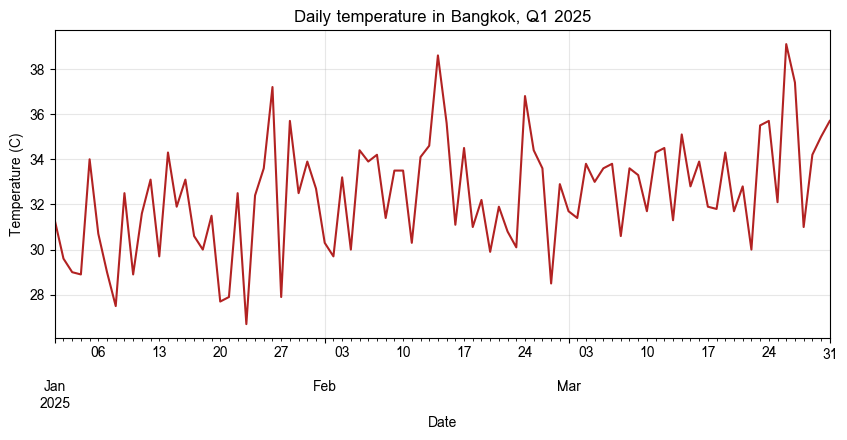

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

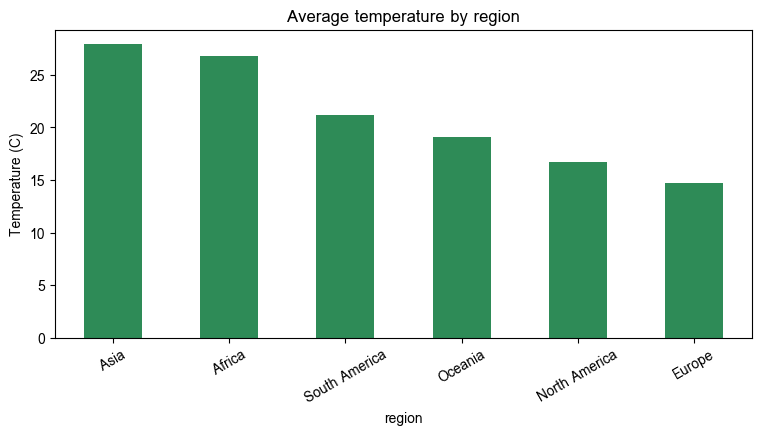

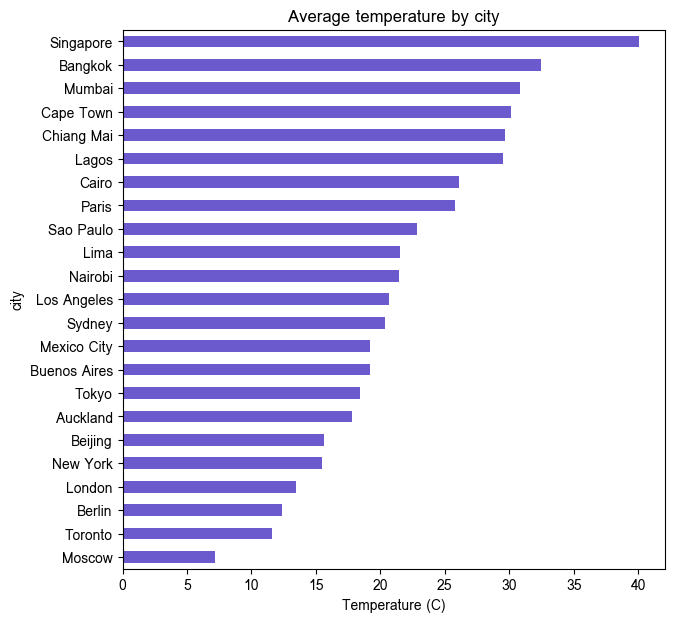

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

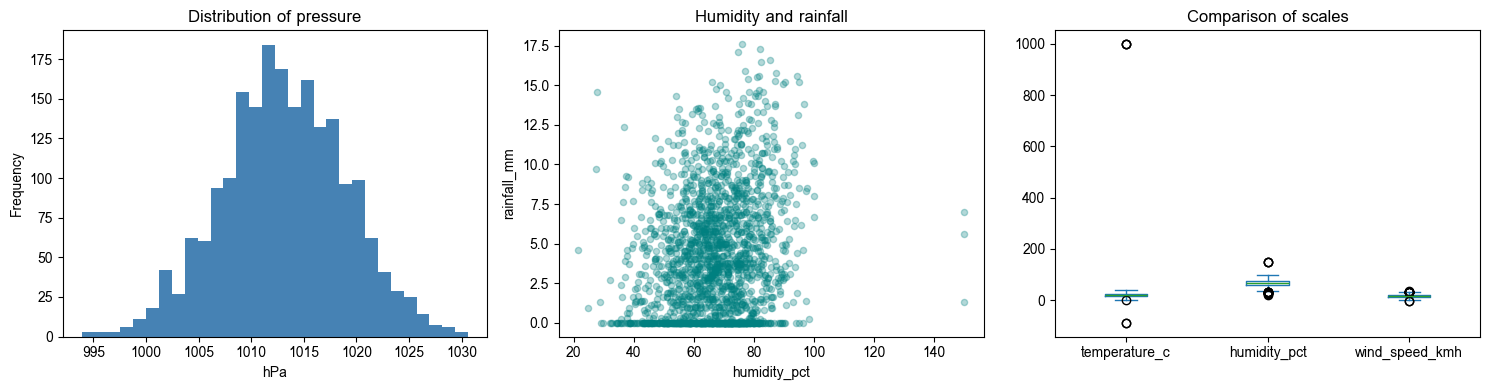

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

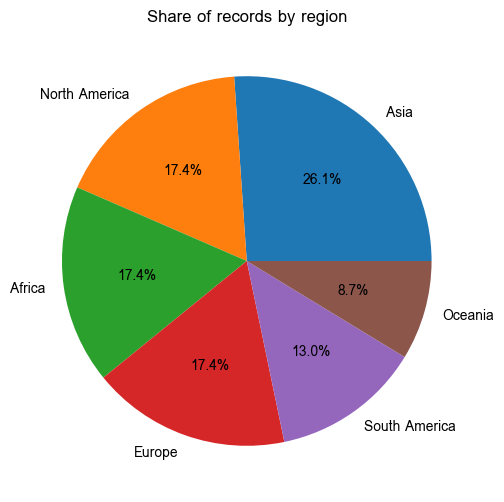

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

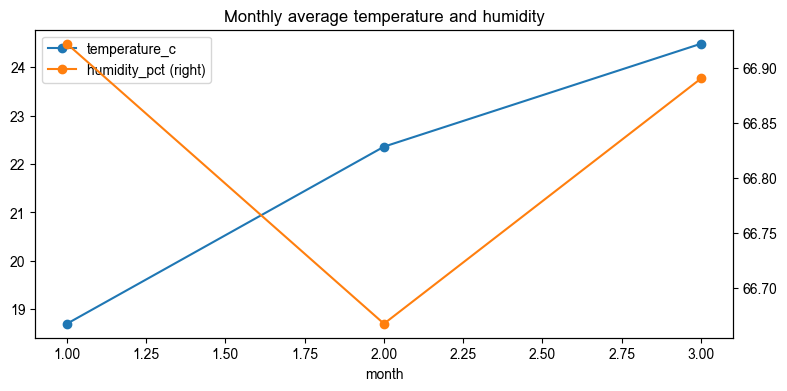

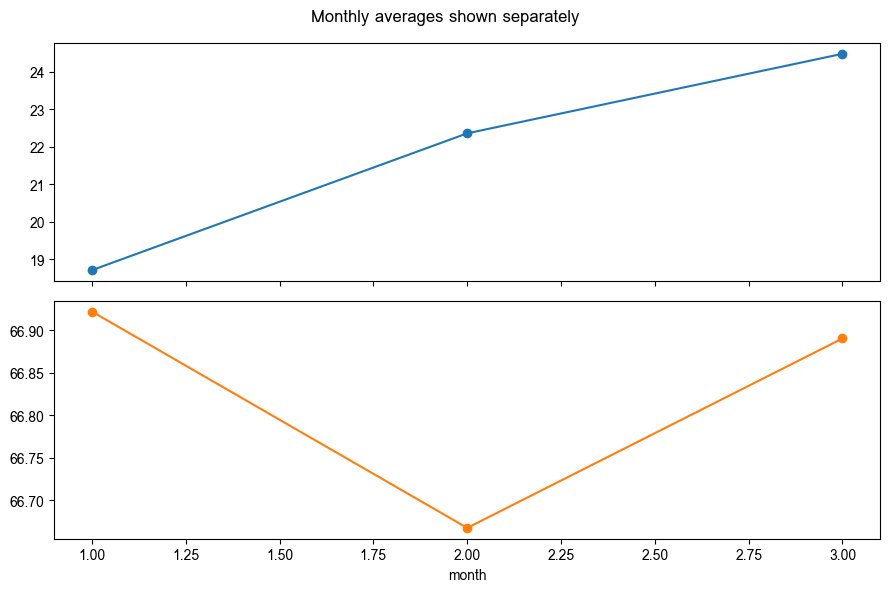

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

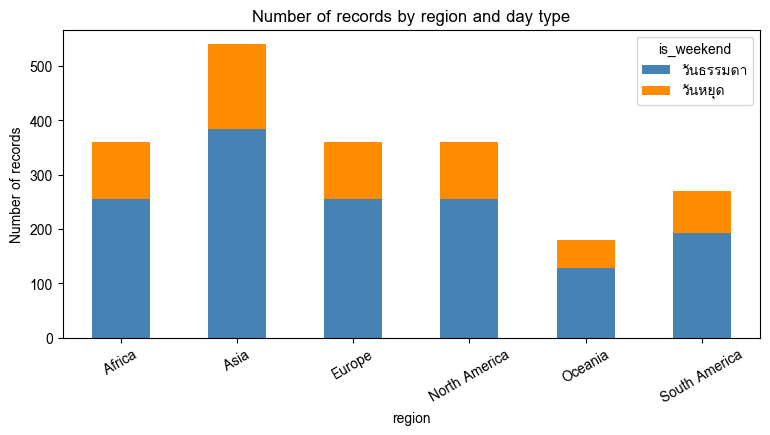

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

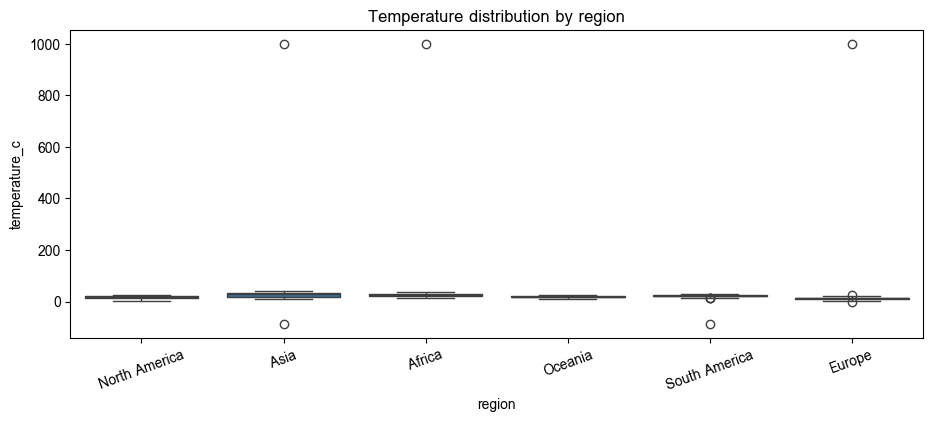

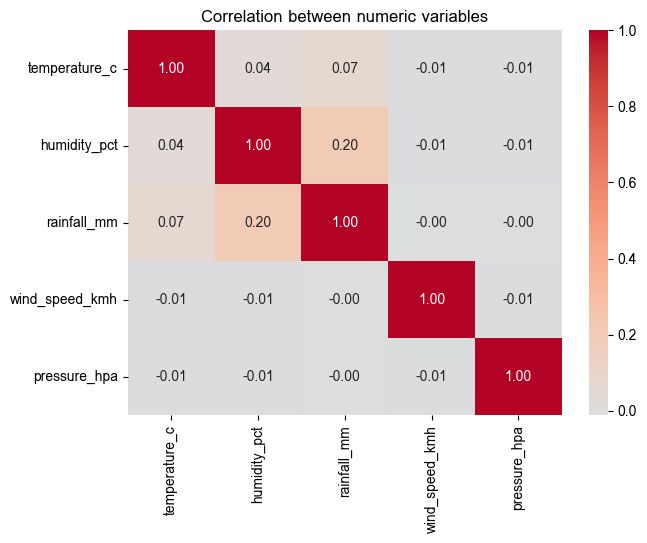

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

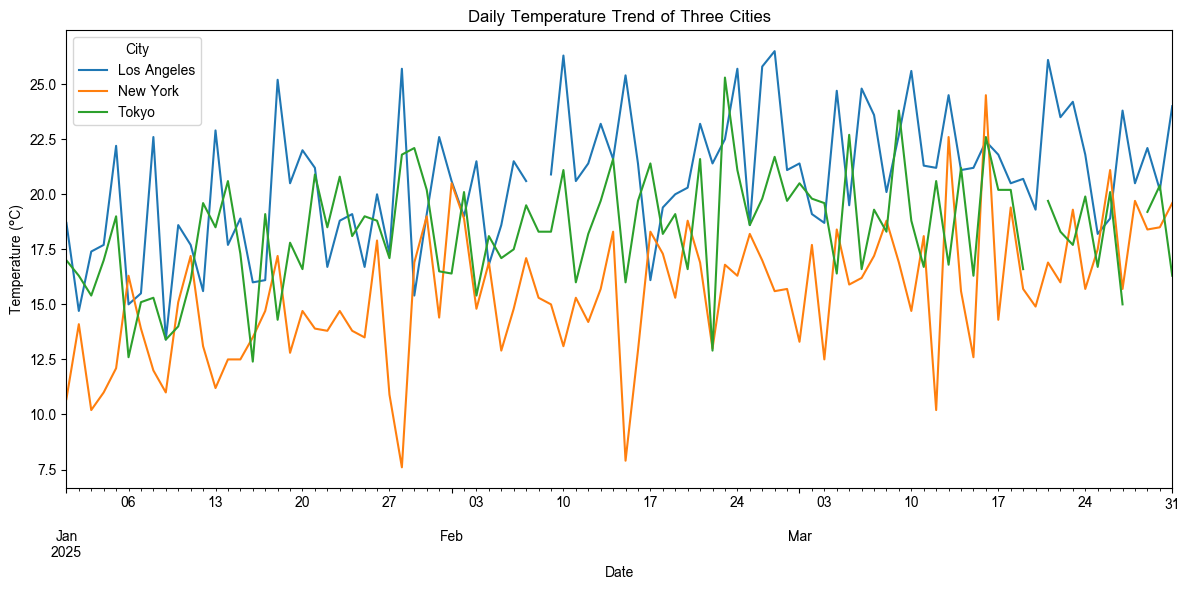

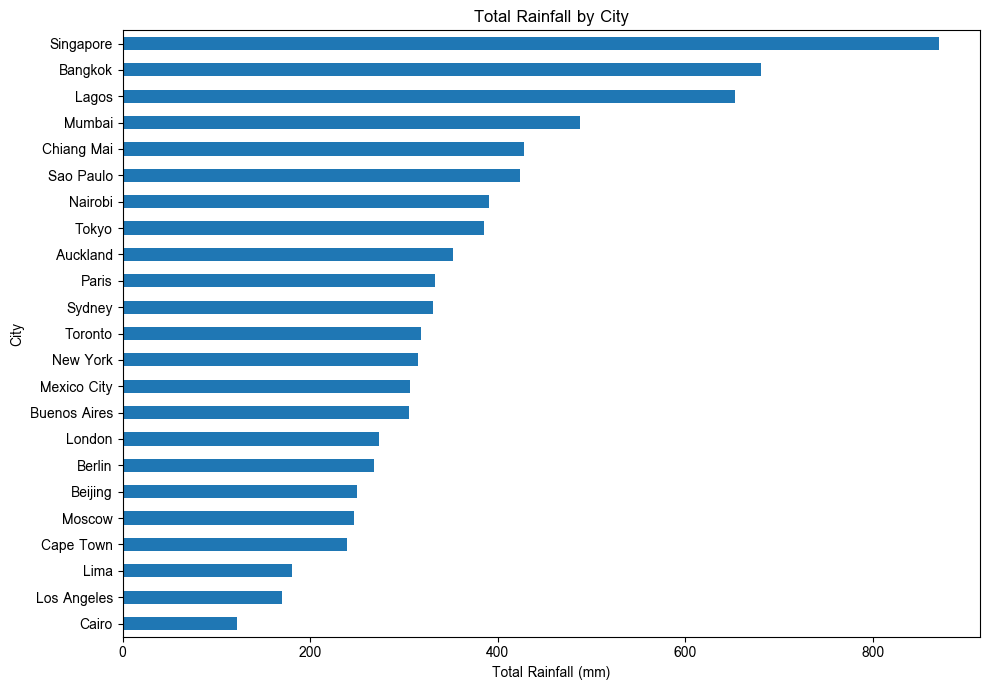

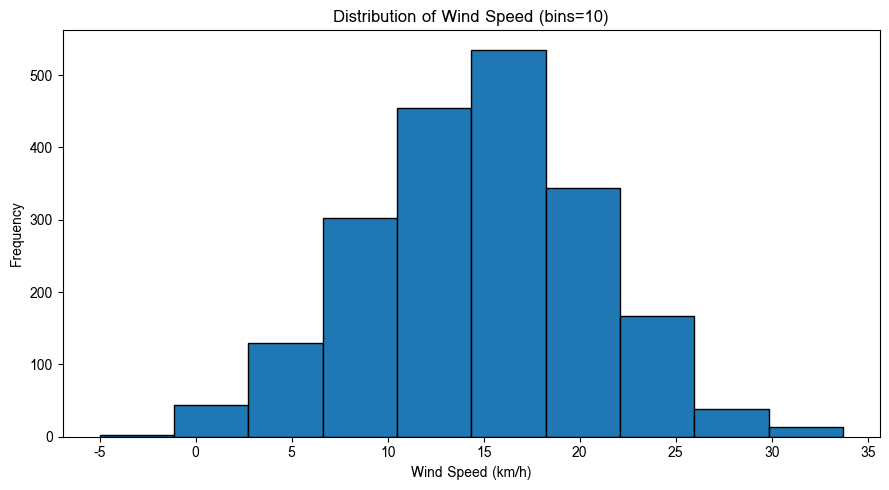

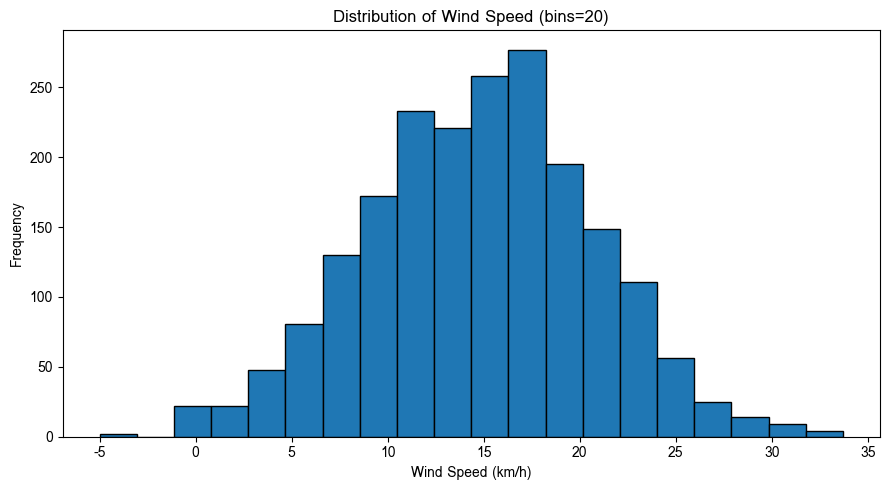

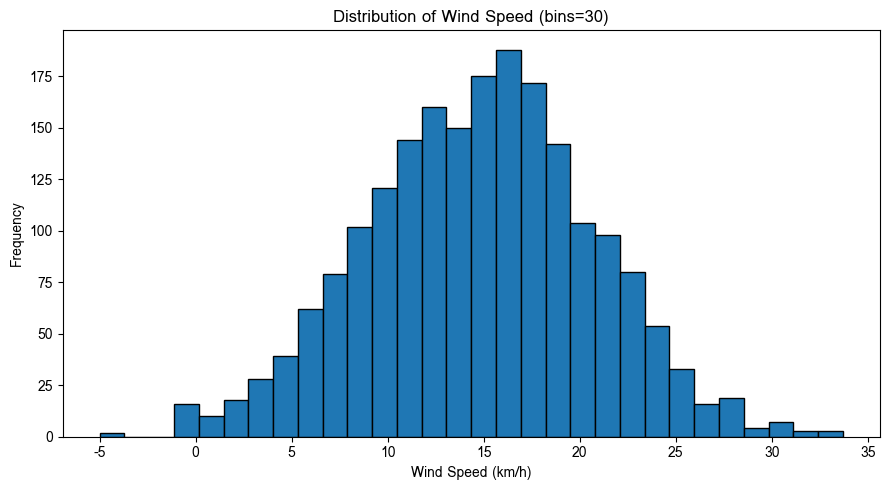

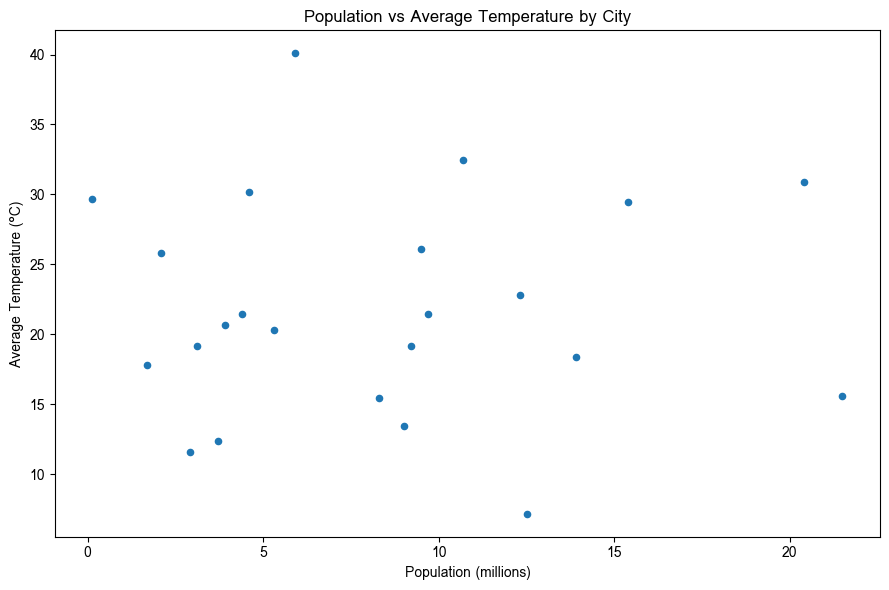

In [123]:
# คำตอบข้อ 17.1
import matplotlib.pyplot as plt

# ============================================================
# 1. Line plot: แนวโน้มอุณหภูมิรายวันของ 3 เมือง
# ============================================================

cities = df["city"].unique()[:3]

line_data = (
    df[df["city"].isin(cities)]
    .pivot(index="date", columns="city", values="temperature_c")
)

line_data.plot(
    kind="line",
    figsize=(12, 6)
)

plt.title("Daily Temperature Trend of Three Cities")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend(title="City")
plt.tight_layout()
plt.show()


# ============================================================
# 2. Horizontal bar: ปริมาณฝนรวมรายเมือง
# ============================================================

rain_by_city = (
    df.groupby("city")["rainfall_mm"]
    .sum()
    .sort_values(ascending=True)
)

rain_by_city.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Total Rainfall by City")
plt.xlabel("Total Rainfall (mm)")
plt.ylabel("City")
plt.tight_layout()
plt.show()


# ============================================================
# 3. Histogram: wind_speed_kmh
# ทดลอง bins = 10, 20, 30
# ============================================================

for bins in [10, 20, 30]:

    df["wind_speed_kmh"].plot(
        kind="hist",
        bins=bins,
        figsize=(9, 5),
        edgecolor="black"
    )

    plt.title(f"Distribution of Wind Speed (bins={bins})")
    plt.xlabel("Wind Speed (km/h)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. Scatter: Population vs Average Temperature
# ============================================================

city_avg = (
    df.groupby("city")["temperature_c"]
    .mean()
    .reset_index(name="avg_temperature")
)

scatter_data = city_avg.merge(
    city_info[["city", "population_millions"]],
    on="city",
    how="left"
)

scatter_data.plot(
    kind="scatter",
    x="population_millions",
    y="avg_temperature",
    figsize=(9, 6)
)

plt.title("Population vs Average Temperature by City")
plt.xlabel("Population (millions)")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

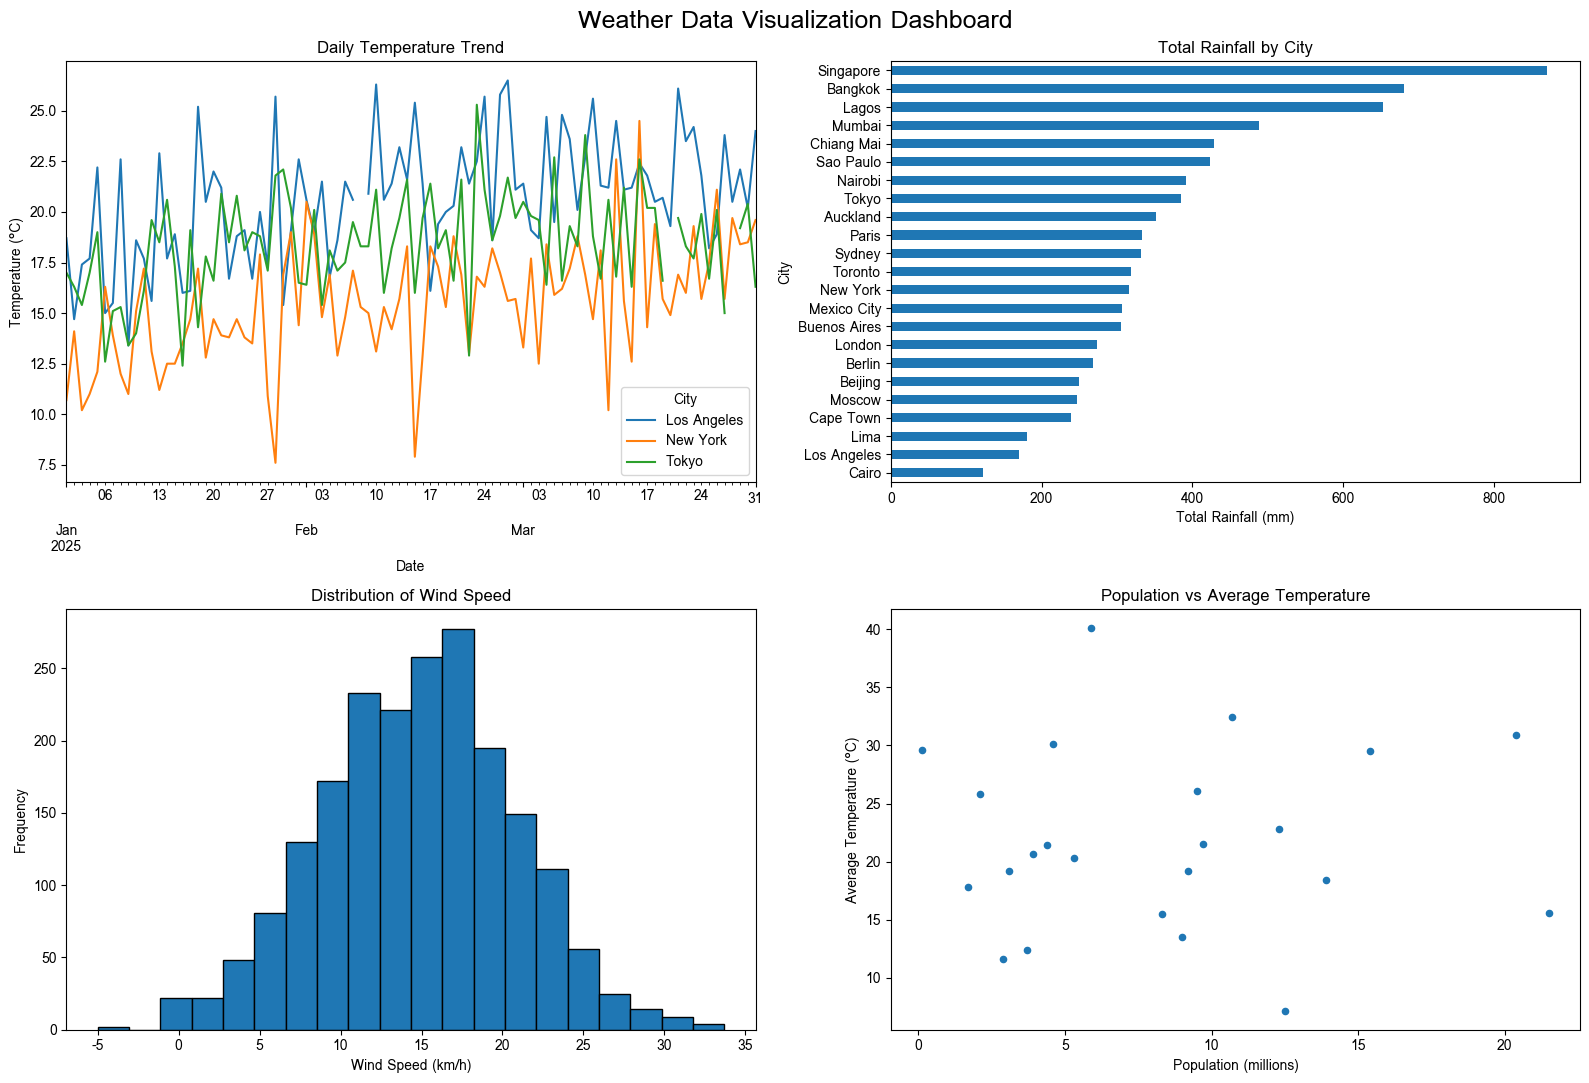

In [124]:
# คำตอบข้อ 17.2
import matplotlib.pyplot as plt

# เตรียมข้อมูล
cities = df["city"].unique()[:3]

line_data = (
    df[df["city"].isin(cities)]
    .pivot(index="date", columns="city", values="temperature_c")
)

rain_by_city = (
    df.groupby("city")["rainfall_mm"]
    .sum()
    .sort_values(ascending=True)
)

city_avg = (
    df.groupby("city")["temperature_c"]
    .mean()
    .reset_index(name="avg_temperature")
)

scatter_data = city_avg.merge(
    city_info[["city", "population_millions"]],
    on="city",
    how="left"
)

# สร้างพื้นที่กราฟ 2 x 2
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# -------------------------
# 1. Line chart
# -------------------------
line_data.plot(
    ax=axes[0, 0],
    kind="line"
)

axes[0, 0].set_title("Daily Temperature Trend")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].legend(title="City")


# -------------------------
# 2. Horizontal bar chart
# -------------------------
rain_by_city.plot(
    ax=axes[0, 1],
    kind="barh"
)

axes[0, 1].set_title("Total Rainfall by City")
axes[0, 1].set_xlabel("Total Rainfall (mm)")
axes[0, 1].set_ylabel("City")


# -------------------------
# 3. Histogram
# -------------------------
df["wind_speed_kmh"].plot(
    ax=axes[1, 0],
    kind="hist",
    bins=20,
    edgecolor="black"
)

axes[1, 0].set_title("Distribution of Wind Speed")
axes[1, 0].set_xlabel("Wind Speed (km/h)")
axes[1, 0].set_ylabel("Frequency")


# -------------------------
# 4. Scatter plot
# -------------------------
scatter_data.plot(
    ax=axes[1, 1],
    kind="scatter",
    x="population_millions",
    y="avg_temperature"
)

axes[1, 1].set_title("Population vs Average Temperature")
axes[1, 1].set_xlabel("Population (millions)")
axes[1, 1].set_ylabel("Average Temperature (°C)")


# ชื่อรวมของภาพ
plt.suptitle(
    "Weather Data Visualization Dashboard",
    fontsize=18
)

plt.tight_layout()
plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

In [125]:
# คำตอบข้อ 17.3
import pandas as pd
import matplotlib.pyplot as plt

# 1. แบ่งช่วงปริมาณฝนด้วย pd.cut()
bins = [-1, 0, 10, 30, 50, float("inf")]
labels = [
    "0 mm",
    "0–10 mm",
    "10–30 mm",
    "30–50 mm",
    ">50 mm"
]

df["rainfall_range"] = pd.cut(
    df["rainfall_mm"],
    bins=bins,
    labels=labels
)

# 2. นับจำนวนวันในแต่ละช่วงปริมาณฝน แยกตามภูมิภาค
rain_region = pd.crosstab(
    df["rainfall_range"],
    df["region"]
)

print(rain_region)

region          Africa  Asia  Europe  North America  Oceania  South America
rainfall_range                                                             
0 mm               101    59     106             92       35             76
0–10 mm            217   377     229            245      128            166
10–30 mm            31    90      15             11        9             21


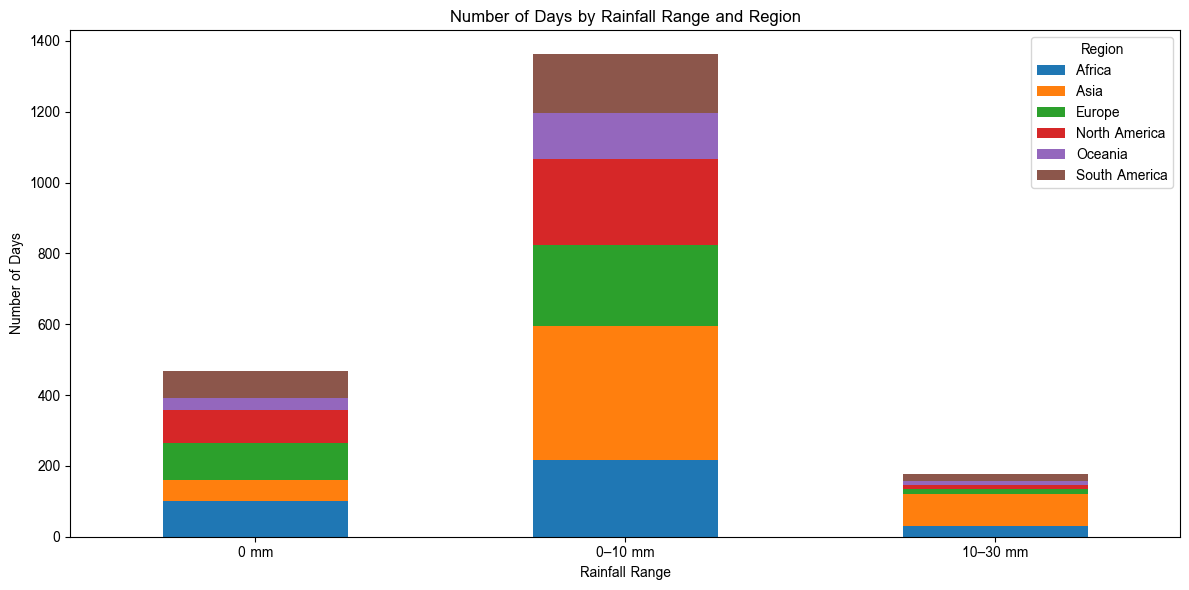

In [126]:
#1. กราฟแท่งซ้อน stacked=True
rain_region.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Number of Days by Rainfall Range and Region")
plt.xlabel("Rainfall Range")
plt.ylabel("Number of Days")
plt.legend(title="Region")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

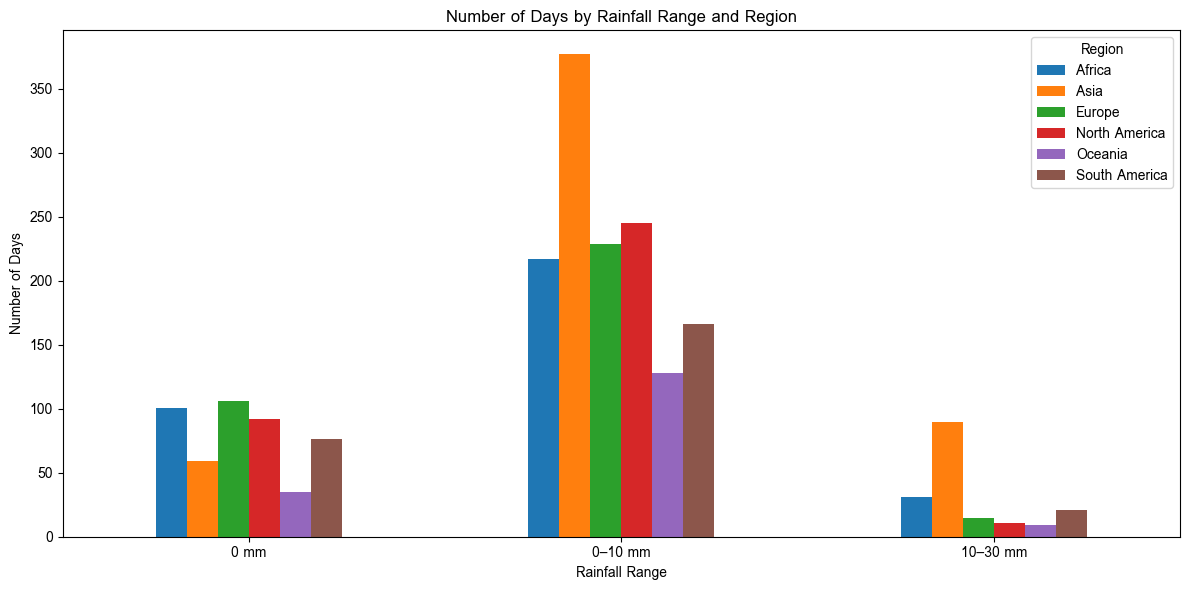

In [127]:
#2. กราฟแท่งเรียงข้างกัน stacked=False
rain_region.plot(
    kind="bar",
    stacked=False,
    figsize=(12, 6)
)

plt.title("Number of Days by Rainfall Range and Region")
plt.xlabel("Rainfall Range")
plt.ylabel("Number of Days")
plt.legend(title="Region")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Stacked

เหมาะเมื่อเราต้องการดูว่า ในช่วงฝนตกหนักแต่ละช่วง มีจำนวนวันรวมเท่าไร และแต่ละภูมิภาคมีส่วนประกอบเท่าไร

Stacked=False

เหมาะเมื่อเราต้องการเปรียบเทียบว่า ภูมิภาคใดมีจำนวนวันในช่วงปริมาณฝนเดียวกันมากกว่ากัน เพราะแท่งของแต่ละภูมิภาคอยู่ข้างกัน ทำให้เทียบความสูงได้ง่ายกว่า

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

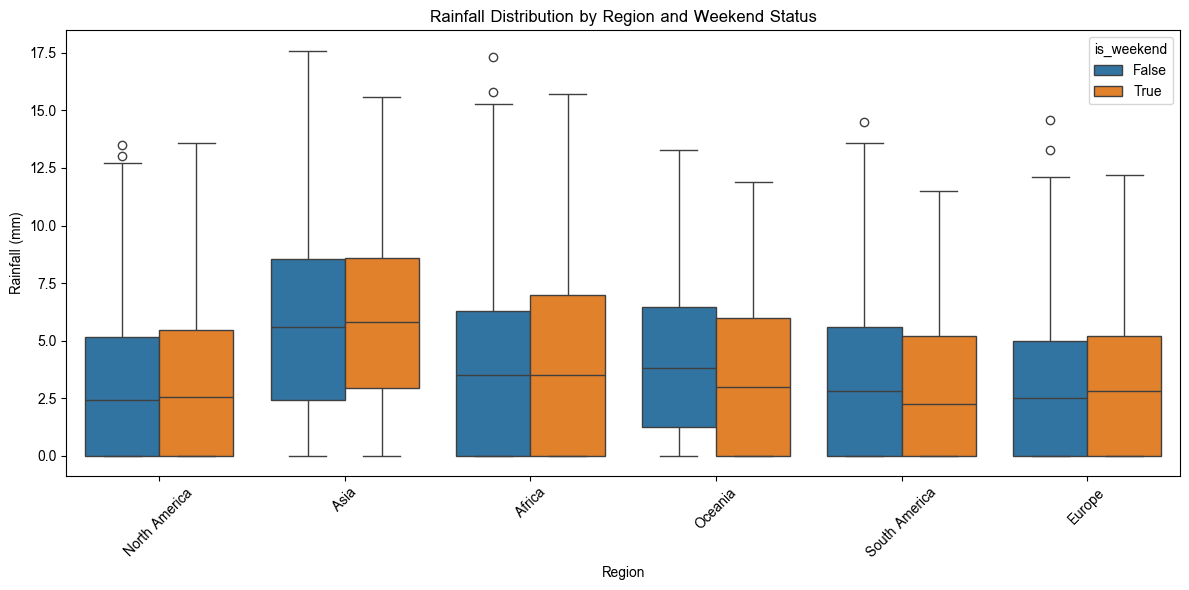

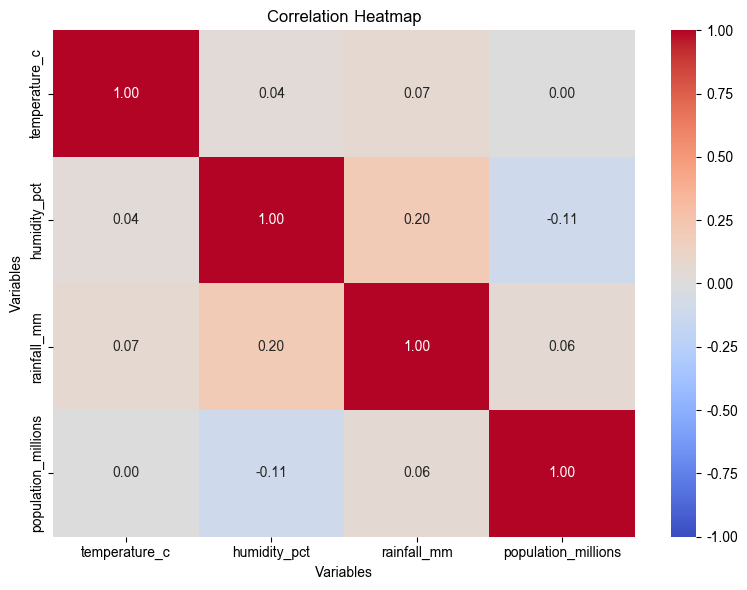

In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# เตรียมข้อมูล
# =========================

df["date"] = pd.to_datetime(df["date"])

# สร้าง is_weekend
df["is_weekend"] = df["date"].dt.dayofweek >= 5

# รวม population_millions จาก city_info เข้ามา
df_plot = df.merge(
    city_info[["city", "population_millions"]],
    on="city",
    how="left"
)

# =========================
# 1. Boxplot
# =========================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_plot,
    x="region",
    y="rainfall_mm",
    hue="is_weekend"
)

plt.title("Rainfall Distribution by Region and Weekend Status")
plt.xlabel("Region")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# =========================
# 2. Heatmap
# =========================

corr_data = df_plot[
    [
        "temperature_c",
        "humidity_pct",
        "rainfall_mm",
        "population_millions"
    ]
]

corr_matrix = corr_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")
plt.xlabel("Variables")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [131]:
# คำตอบข้อ 18.1
import pandas as pd

# เลือกข้อมูลไตรมาสแรก (มกราคม–มีนาคม)
q1 = merged[
    merged["date"].dt.month.isin([1, 2, 3])
].copy()

# สรุป SD อุณหภูมิรายวันของแต่ละเมือง
city_sd = (
    q1.groupby(["region", "city"])["temperature_c"]
      .std()
      .reset_index(name="temp_sd")
)

# สรุประดับภูมิภาค
result_18_1 = (
    city_sd.groupby("region")
           .agg(
               region_sd=("temp_sd", "mean"),
               max_city_sd=("temp_sd", "max"),
               min_city_sd=("temp_sd", "min"),
               city_count=("city", "count")
           )
           .reset_index()
)

# วัดความแตกต่างของ SD ระหว่างเมืองในภูมิภาค
result_18_1["sd_range"] = (
    result_18_1["max_city_sd"] -
    result_18_1["min_city_sd"]
)

# เรียงจากภูมิภาคที่แปรปรวนมากที่สุด
result_18_1 = result_18_1.sort_values(
    "region_sd",
    ascending=False
)

print(result_18_1.round(2))

          region  region_sd  max_city_sd  min_city_sd  city_count  sd_range
2         Europe      28.22       104.37         2.60           4    101.78
0         Africa      28.08       103.90         2.74           4    101.16
1           Asia      19.38       103.01         2.49           6    100.52
5  South America       5.91        11.82         2.79           3      9.03
3  North America       2.87         3.02         2.71           4      0.31
4        Oceania       2.81         2.82         2.80           2      0.02


2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [132]:
# คำตอบข้อ 18.2
# สร้างตัวแปรว่าฝนตกหนักหรือไม่
df["heavy_rain"] = df["rainfall_mm"] >= 20

# สรุปจำนวนวันทั้งหมดและจำนวนวันฝนตกหนักของแต่ละเมือง
rain_city = (
    df.groupby("city")
      .agg(
          total_days=("rainfall_mm", "count"),
          heavy_rain_days=("heavy_rain", "sum")
      )
      .reset_index()
)

# คำนวณสัดส่วนวันฝนตกหนัก
rain_city["heavy_rain_pct"] = (
    rain_city["heavy_rain_days"] /
    rain_city["total_days"] * 100
)

# เรียงตามสัดส่วนและเลือก 5 อันดับแรก
top5_rain = (
    rain_city
    .sort_values("heavy_rain_pct", ascending=False)
    .head(5)
)

print(top5_rain.round(2))

           city  total_days  heavy_rain_days  heavy_rain_pct
0      Auckland          85                0             0.0
1       Bangkok          87                0             0.0
2       Beijing          88                0             0.0
3        Berlin          87                0             0.0
4  Buenos Aires          88                0             0.0


3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [133]:
# คำตอบข้อ 18.3
# รวม population เข้ากับข้อมูลสภาพอากาศ
df_corr = df.merge(
    city_info[["city", "population_millions"]],
    on="city",
    how="left"
)

# คำนวณค่าเฉลี่ยรายเมืองก่อน
city_corr = (
    df_corr.groupby("city")
           .agg(
               population_millions=("population_millions", "first"),
               avg_temperature=("temperature_c", "mean"),
               avg_rainfall=("rainfall_mm", "mean")
           )
           .reset_index()
)

# คำนวณ Pearson correlation
correlation = city_corr[
    ["population_millions", "avg_temperature", "avg_rainfall"]
].corr()

print(correlation.round(3))

                     population_millions  avg_temperature  avg_rainfall
population_millions                1.000            0.014         0.123
avg_temperature                    0.014            1.000         0.656
avg_rainfall                       0.123            0.656         1.000


4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

In [134]:
# คำตอบข้อ 18.4
# เตรียมข้อมูลเดือน
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# สรุปสภาพอากาศรายเดือนของแต่ละภูมิภาค
travel_risk = (
    df.groupby(["region", "month"])
      .agg(
          avg_rainfall=("rainfall_mm", "mean"),
          avg_wind_speed=("wind_speed_kmh", "mean")
      )
      .reset_index()
)

# จัดอันดับภายในแต่ละภูมิภาค
travel_risk["rain_rank"] = (
    travel_risk.groupby("region")["avg_rainfall"]
               .rank(pct=True)
)

travel_risk["wind_rank"] = (
    travel_risk.groupby("region")["avg_wind_speed"]
               .rank(pct=True)
)

# คะแนนความเสี่ยง = ฝน 50% + ลม 50%
travel_risk["risk_score"] = (
    travel_risk["rain_rank"] * 0.5 +
    travel_risk["wind_rank"] * 0.5
)

# เดือนที่ควรหลีกเลี่ยงที่สุดของแต่ละภูมิภาค
worst_month = (
    travel_risk.loc[
        travel_risk.groupby("region")["risk_score"].idxmax()
    ]
    .sort_values("region")
)

print(
    worst_month[
        [
            "region",
            "month",
            "avg_rainfall",
            "avg_wind_speed",
            "risk_score"
        ]
    ].round(2)
)

           region  month  avg_rainfall  avg_wind_speed  risk_score
0          Africa      1          4.22           15.59        1.00
3            Asia      1          5.68           15.09        0.67
6          Europe      1          3.30           14.86        0.83
10  North America      2          3.26           14.88        0.83
14        Oceania      3          4.38           14.55        0.83
16  South America      2          3.68           14.46        0.83


---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️